# VA DEQ & StreamStats Feature Engineering

The purpose of this Jupyter notebook is to load data cleaned in another notebook and transform the data appropriately. This dataset will be ready for model training.

Emma Reilly Oare

In [17]:
!pip uninstall numpy -y
!pip uninstall pandas -y
!pip install numpy
!pip install pandas

Found existing installation: numpy 1.25.2
Uninstalling numpy-1.25.2:
  Successfully uninstalled numpy-1.25.2
Found existing installation: pandas 2.0.2
Uninstalling pandas-2.0.2:


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\shutil.py", line 853, in move
    os.rename(src, real_dst)
PermissionError: [WinError 5] Access is denied: 'c:\\program files\\arcgis\\pro\\bin\\python\\envs\\arcgispro-py3\\lib\\site-packages\\pandas-2.0.2.dist-info\\' -> 'C:\\Users\\reill\\AppData\\Local\\Temp\\pip-uninstall-lzltgh_u'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\pip\_internal\cli\base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\pip\_internal\commands\uninstall.py", line 105, in run
    uninstall_pathset = req.uninstall(
                        ^^^^^^^^^^^^^^
  File "C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcg

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [21]:
!python -m venv myenv
!myenv\Scripts\activate
!pip install jupyter numpy pandas scipy

Defaulting to user installation because normal site-packages is not writeable
   -------------------------------------- 246.9/246.9 kB 688.0 kB/s eta 0:00:00
   ---------------------------------------- 80.9/80.9 kB 2.3 MB/s eta 0:00:00


In [23]:
!pip install ipykernel
!python -m ipykernel install --user --name=myenv --display-name "Python (myenv)"


Defaulting to user installation because normal site-packages is not writeable
Installed kernelspec myenv in C:\Users\reill\AppData\Roaming\jupyter\kernels\myenv


In [24]:
import sys
print(sys.executable)

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\python.exe


In [13]:
!pip install ipykernel
!python -m ipykernel install --user --name=myenv --display-name "Python (myenv)"


Defaulting to user installation because normal site-packages is not writeable
Installed kernelspec myenv in C:\Users\reill\AppData\Roaming\jupyter\kernels\myenv


In [15]:
# Read in libs
import os 
import warnings 
import pandas as pd  
import numpy as np
import scipy.stats as stats 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, PowerTransformer, QuantileTransformer 

# Suppress warnings
warnings.filterwarnings("ignore")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

## Step 1. Import dataset

In [2]:
# Define base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

In [3]:
# Read in file
vadeq_path = os.path.join(BASE_DIR, "data", "processed", "virginia", "vadeq_strmsts_after_eda.xlsx")
vadeq_strmsts = pd.read_excel(vadeq_path).drop(columns = ['Unnamed: 0'])

In [4]:
# Display data frame
vadeq_strmsts

,StationID,Date,LATITUDE,LONGITUDE,Bankfull Shear Velocity (m/s),Xembed,STATSGODEP,ELEV,STATSCLY20,RELIEF,...,LC11CRPHAY,I24H2Y,PRECIP,Year,DRNAREA,Peak Flow #: 1551,Peak Flow #: 1552,Peak Flow #: 1553,Peak Flow #: 1554,Peak Flow #: 1555
0,1AACO006.10,2006-11-21,38.728611,-77.203333,0.147072,62.545455,70.48,148.98,0.00,171.0,...,0.00,3.140,43.078,2006,0.0702,True,False,False,False,False
1,1AACO004.84,2008-06-25,38.720500,-77.190722,0.211670,51.636364,66.65,308.44,51.85,451.0,...,0.11,3.167,43.888,2008,40.5000,False,False,False,False,False
2,1AACO006.10,2008-06-26,38.728611,-77.203333,0.129573,56.818182,70.48,148.98,0.00,171.0,...,0.00,3.140,43.078,2008,0.0702,True,False,False,False,False
3,1AACO009.14,2008-06-26,38.761944,-77.207222,0.130071,63.454545,66.39,324.56,54.64,357.0,...,0.09,3.169,43.981,2008,36.3000,True,False,False,False,False
4,1AAUA017.60,2005-09-22,38.490361,-77.466389,0.161058,65.454545,56.77,317.16,0.30,278.0,...,7.74,3.055,43.317,2005,29.7000,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,2BXRK001.64,2022-10-26,37.811383,-78.729900,0.228096,67.090909,68.00,796.84,0.00,575.0,...,0.00,3.723,49.307,2022,0.7600,False,False,True,False,False
1113,2-JKS070.06,2022-09-12,38.123444,-79.779725,0.248010,27.636364,44.64,2821.90,69.18,2550.0,...,17.98,2.959,43.163,2022,104.0000,False,False,False,True,False
1114,4ASNA007.82,2022-09-20,36.792139,-79.112444,0.196710,95.909091,71.04,604.47,0.00,691.0,...,23.17,3.319,45.609,2022,79.9000,True,False,False,False,False
1115,8-MIC001.47,2022-10-25,37.753450,-77.720931,0.114323,89.090909,72.00,298.12,0.00,197.0,...,49.07,3.290,43.671,2022,5.6500,True,False,False,False,False


## Step 2. Feature Engineering

We will explore transforming the feature sets to more closely follow a Gaussian distribution. We will use visual and statistical methods to select the best transformation tested. We will test:
- log
- square root
- power
- box-cox
- reciprocal
- Yeo-Johnson Power Transformation
- Normal Quantile Transformation

We will go through each feature individually below.

### 2a. Visualize Transformations

In [5]:
# Define function for applying transformations
def apply_transformation(data, transform):
    if transform == 'log':
        return np.log(data + 1)
    elif transform == 'sqrt':
        return np.sqrt(data)
    elif transform == 'cbrt':
        return np.power(data, 1/3)
    elif transform == 'boxcox':
        if (data > 0).all():
            return stats.boxcox(data)[0]
        else:
            return None
    elif transform == 'reciprocal':
        return 1 / (data + 1)
    elif transform == 'yeo_johnson':
        pt = PowerTransformer(method='yeo-johnson')
        return pt.fit_transform(data.values.reshape(-1, 1)).flatten()
    elif transform == 'quantile_normal':
        qt = QuantileTransformer(output_distribution='normal')
        return qt.fit_transform(data.values.reshape(-1, 1)).flatten()
    else:
        return data

# Define function for evaluating normality based on statistical measures (Shapiro and Anderson)
def evaluate_normality(data):
    shapiro_stat, shapiro_p_value = stats.shapiro(data)
    ad_stat, ad_critical_values, ad_significance_level = stats.anderson(data, dist='norm')
    return {
        'shapiro_stat': shapiro_stat,
        'shapiro_p_value': shapiro_p_value,
        'ad_stat': ad_stat,
        'ad_significance_level': ad_significance_level
    }

# Define function that uses apply_transformation and evaluate_normality to visualize and test for normality
def normality(data, feature):
    transformations = {
        'Original': None,
        'Log': 'log',
        'Square Root': 'sqrt',
        'Cube Root': 'cbrt',
        'Box-Cox': 'boxcox',
        'Reciprocal': 'reciprocal',
        'Yeo-Johnson': 'yeo_johnson',
        'Quantile Normal': 'quantile_normal'
    }

    results = {}

    fig, axes = plt.subplots(len(transformations), 2, figsize=(15, 5 * len(transformations)))

    # Handle infinite values in the original data
    original_data = data[feature].replace([np.inf, -np.inf], np.nan).dropna()

    for i, (name, transform) in enumerate(transformations.items()):
        if transform is None:
            transformed_data = original_data
        else:
            transformed_data = apply_transformation(original_data, transform)
            if transformed_data is None:
                axes[i, 0].set_visible(False)
                axes[i, 1].set_visible(False)
                continue

        # Plot two normality plots ---> KDE and Q-Q
        sns.kdeplot(transformed_data, ax=axes[i, 0])
        axes[i, 0].set_title(f'{name} KDE')
        stats.probplot(transformed_data, plot=axes[i, 1])
        axes[i, 1].set_title(f'{name} Q-Q plot')

        # Evaluate normality
        result = evaluate_normality(transformed_data)
        results[name] = result

    plt.tight_layout()
    plt.show()

    # Print the results
    for name, result in results.items():
        print(f'{name} Transformation:')
        print(f'  Shapiro-Wilk Test Statistic = {result["shapiro_stat"]:.4f}, p-value = {result["shapiro_p_value"]:.4f}')
        print(f'  Anderson-Darling Test Statistic = {result["ad_stat"]:.4f}, Significance Level = {result["ad_significance_level"]}\n')

    # Find and print the best transformation based on Shapiro-Wilk Test
    best_transformation = max(results, key=lambda x: results[x]['shapiro_stat'])
    print(f'Best transformation according to Shapiro-Wilk Test: {best_transformation}')

    # Find and print the best transformation based on Anderson-Darling Test
    best_ad_transformation = min(results, key=lambda x: results[x]['ad_stat'])
    print(f'Best transformation according to Anderson-Darling Test: {best_ad_transformation}')

#### Bankfull Shear Velocity (m/s)

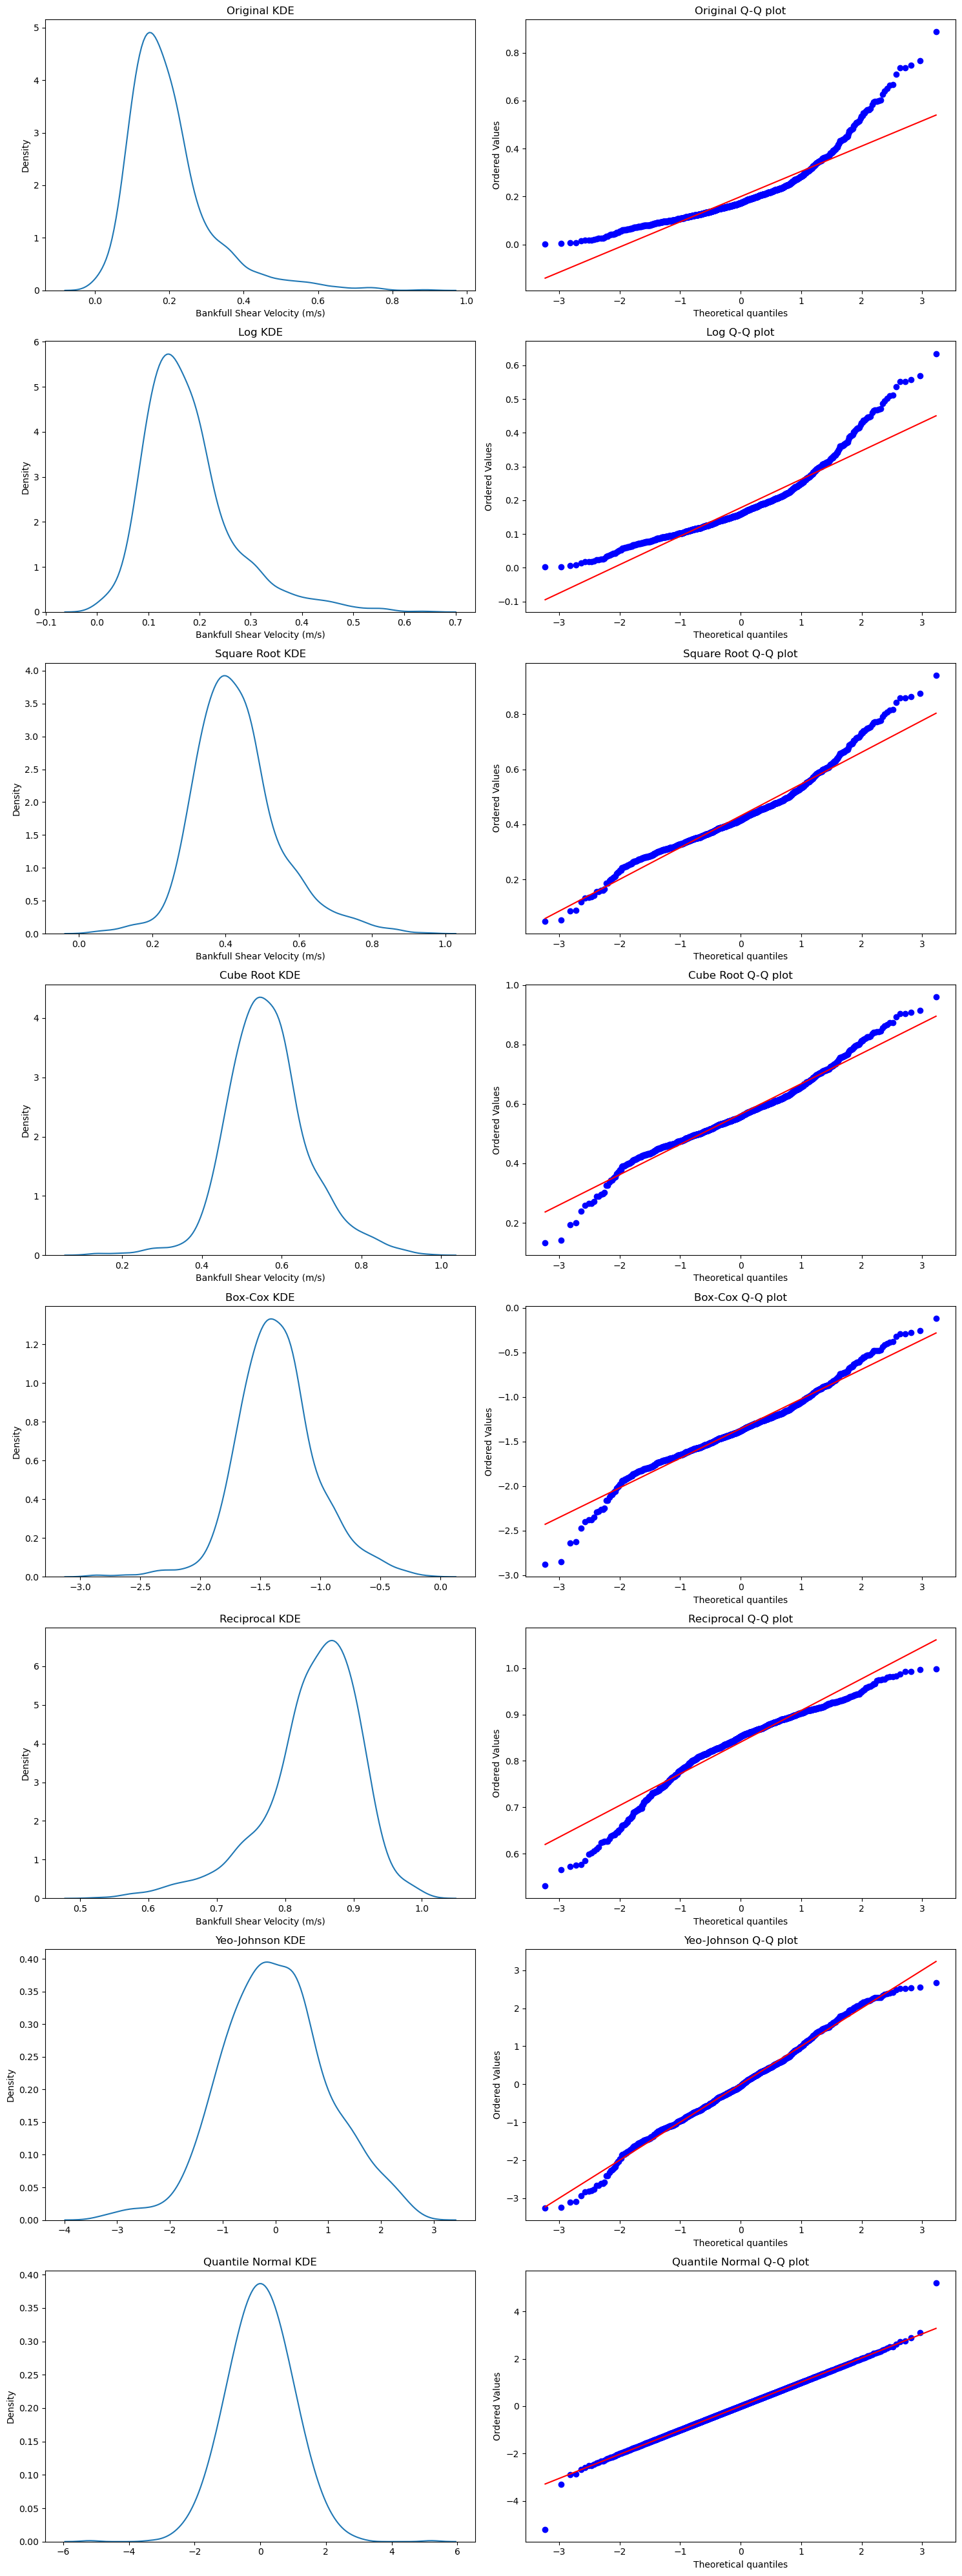

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.8611, p-value = 0.0000
  Anderson-Darling Test Statistic = 37.7399, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9071, p-value = 0.0000
  Anderson-Darling Test Statistic = 25.8094, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9636, p-value = 0.0000
  Anderson-Darling Test Statistic = 11.1929, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9766, p-value = 0.0000
  Anderson-Darling Test Statistic = 6.8408, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9770, p-value = 0.0000
  Anderson-Darling Test Statistic = 6.0934, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.9429, p-value = 0.0000
  Anderson-Darling Test Statistic = 16.5

In [6]:
# Normality plots for Bankfull Shear Velocity feature
normality(vadeq_strmsts, 'Bankfull Shear Velocity (m/s)')

#### STATSGODEP

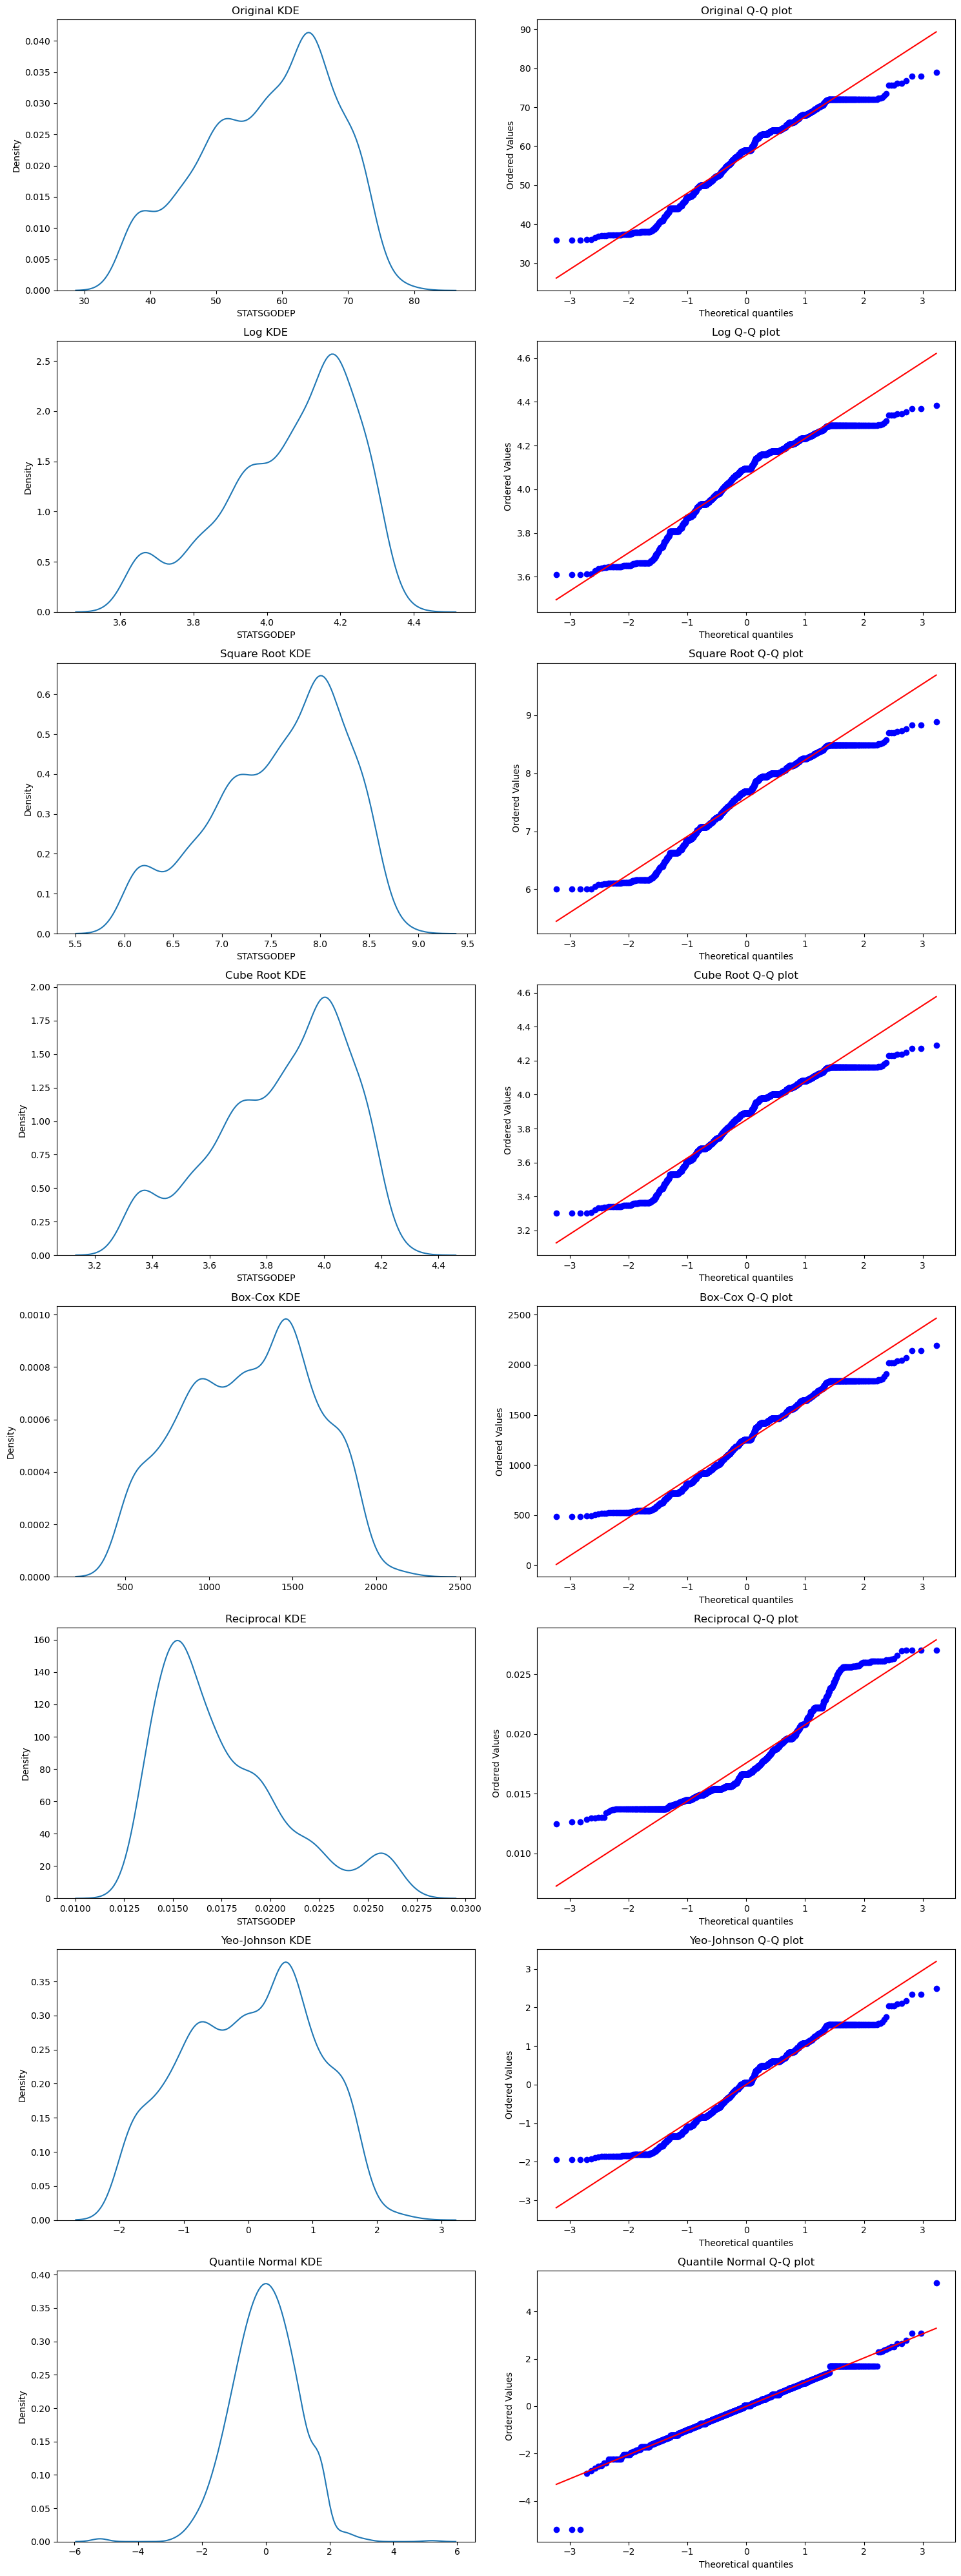

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.9620, p-value = 0.0000
  Anderson-Darling Test Statistic = 11.5390, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9384, p-value = 0.0000
  Anderson-Darling Test Statistic = 20.0333, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9518, p-value = 0.0000
  Anderson-Darling Test Statistic = 15.2256, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9476, p-value = 0.0000
  Anderson-Darling Test Statistic = 16.7459, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9712, p-value = 0.0000
  Anderson-Darling Test Statistic = 8.0396, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.9008, p-value = 0.0000
  Anderson-Darling Test Statistic = 33.

In [7]:
# Normality plots for STATSGODEP feature
normality(vadeq_strmsts, 'STATSGODEP')

#### ELEV

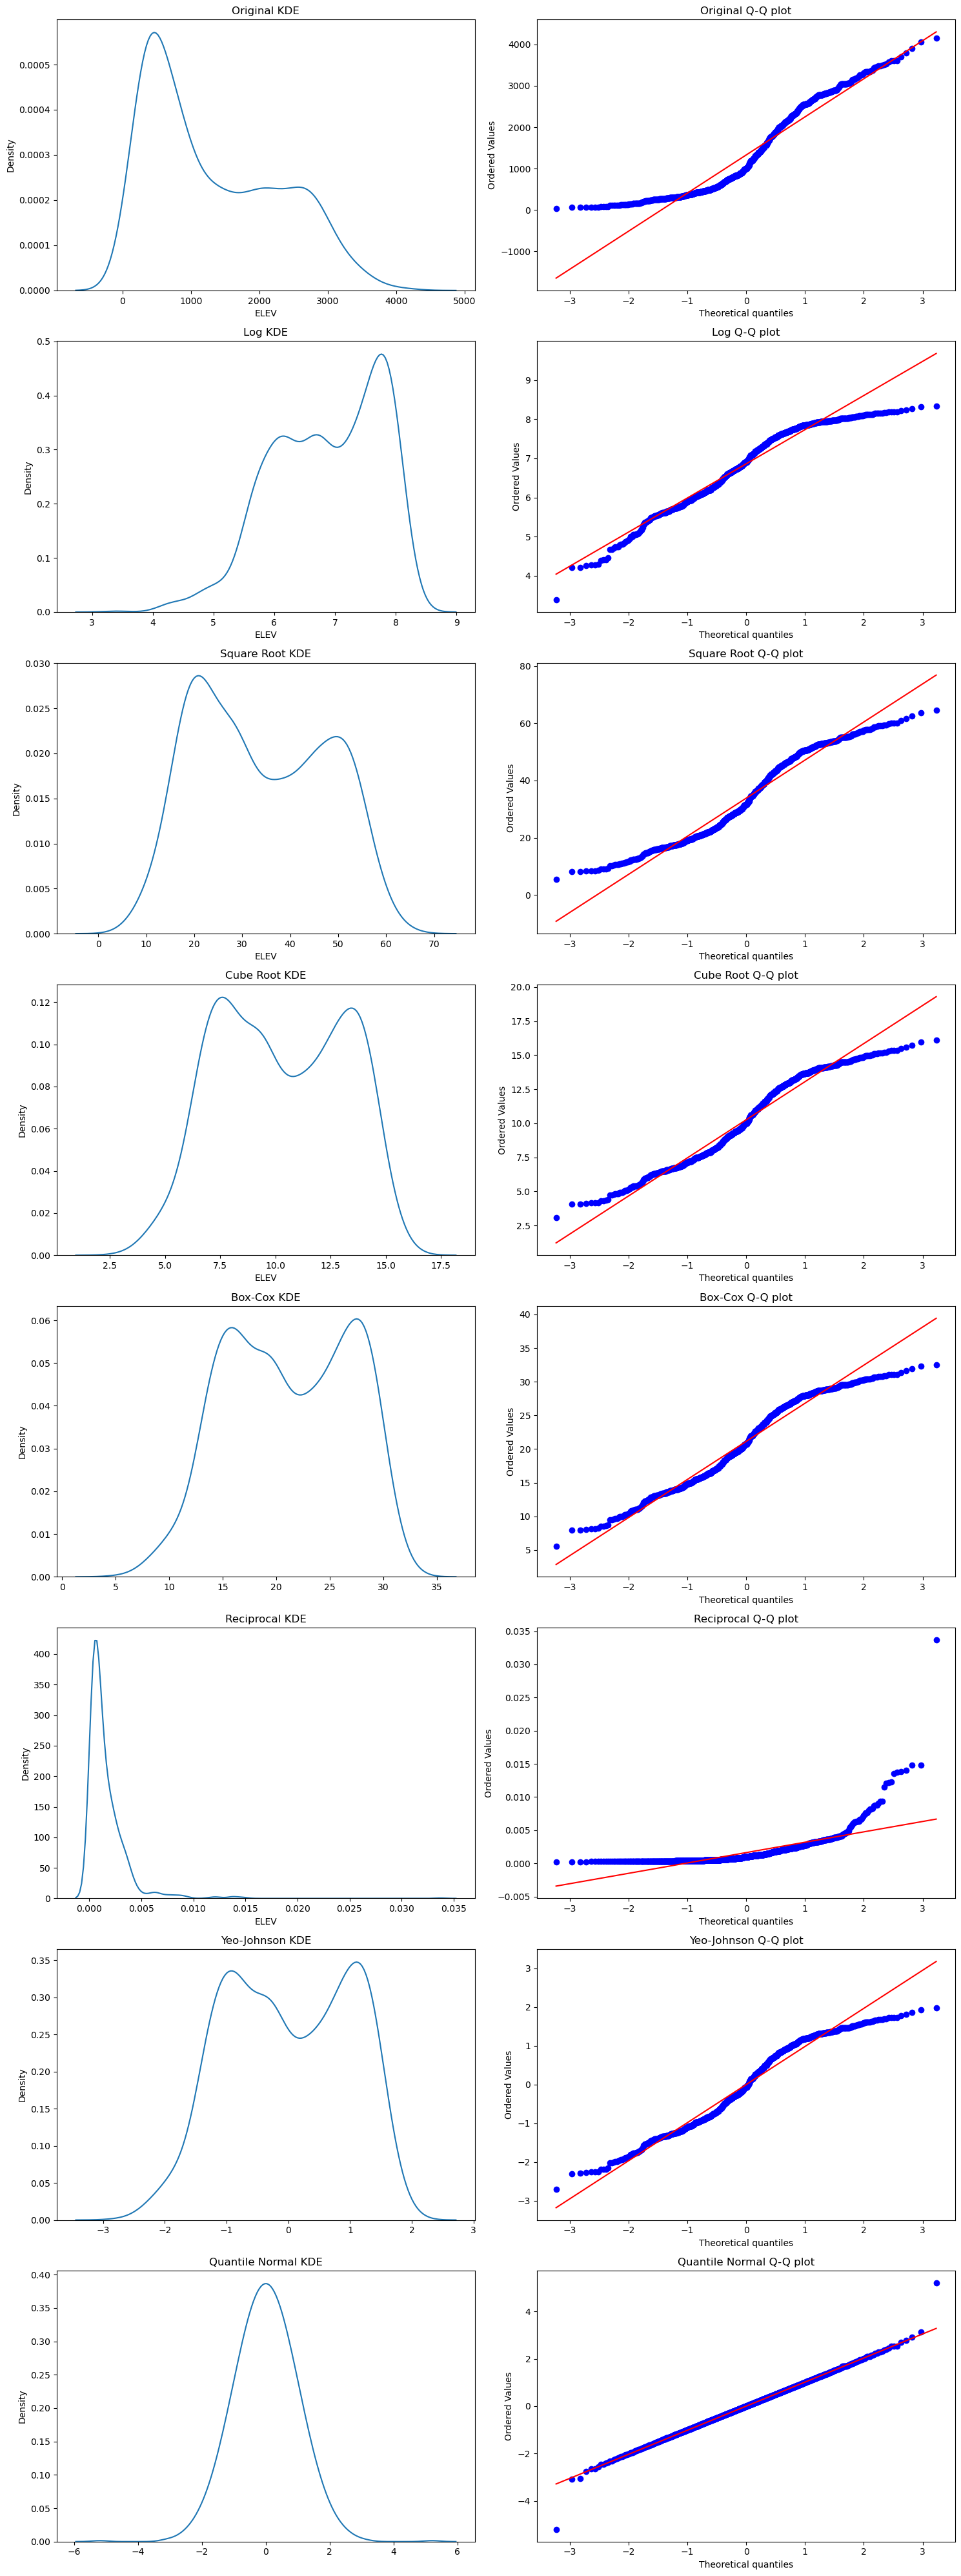

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.9113, p-value = 0.0000
  Anderson-Darling Test Statistic = 35.4765, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9527, p-value = 0.0000
  Anderson-Darling Test Statistic = 15.3814, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9533, p-value = 0.0000
  Anderson-Darling Test Statistic = 18.2029, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9604, p-value = 0.0000
  Anderson-Darling Test Statistic = 15.1635, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9615, p-value = 0.0000
  Anderson-Darling Test Statistic = 14.5567, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.5733, p-value = 0.0000
  Anderson-Darling Test Statistic = 10

In [8]:
# Normality plots for ELEV feature
normality(vadeq_strmsts, 'ELEV')

#### Peak Flow # --> Not transformed given it is a category/group/cluster

#### STATSCLY20

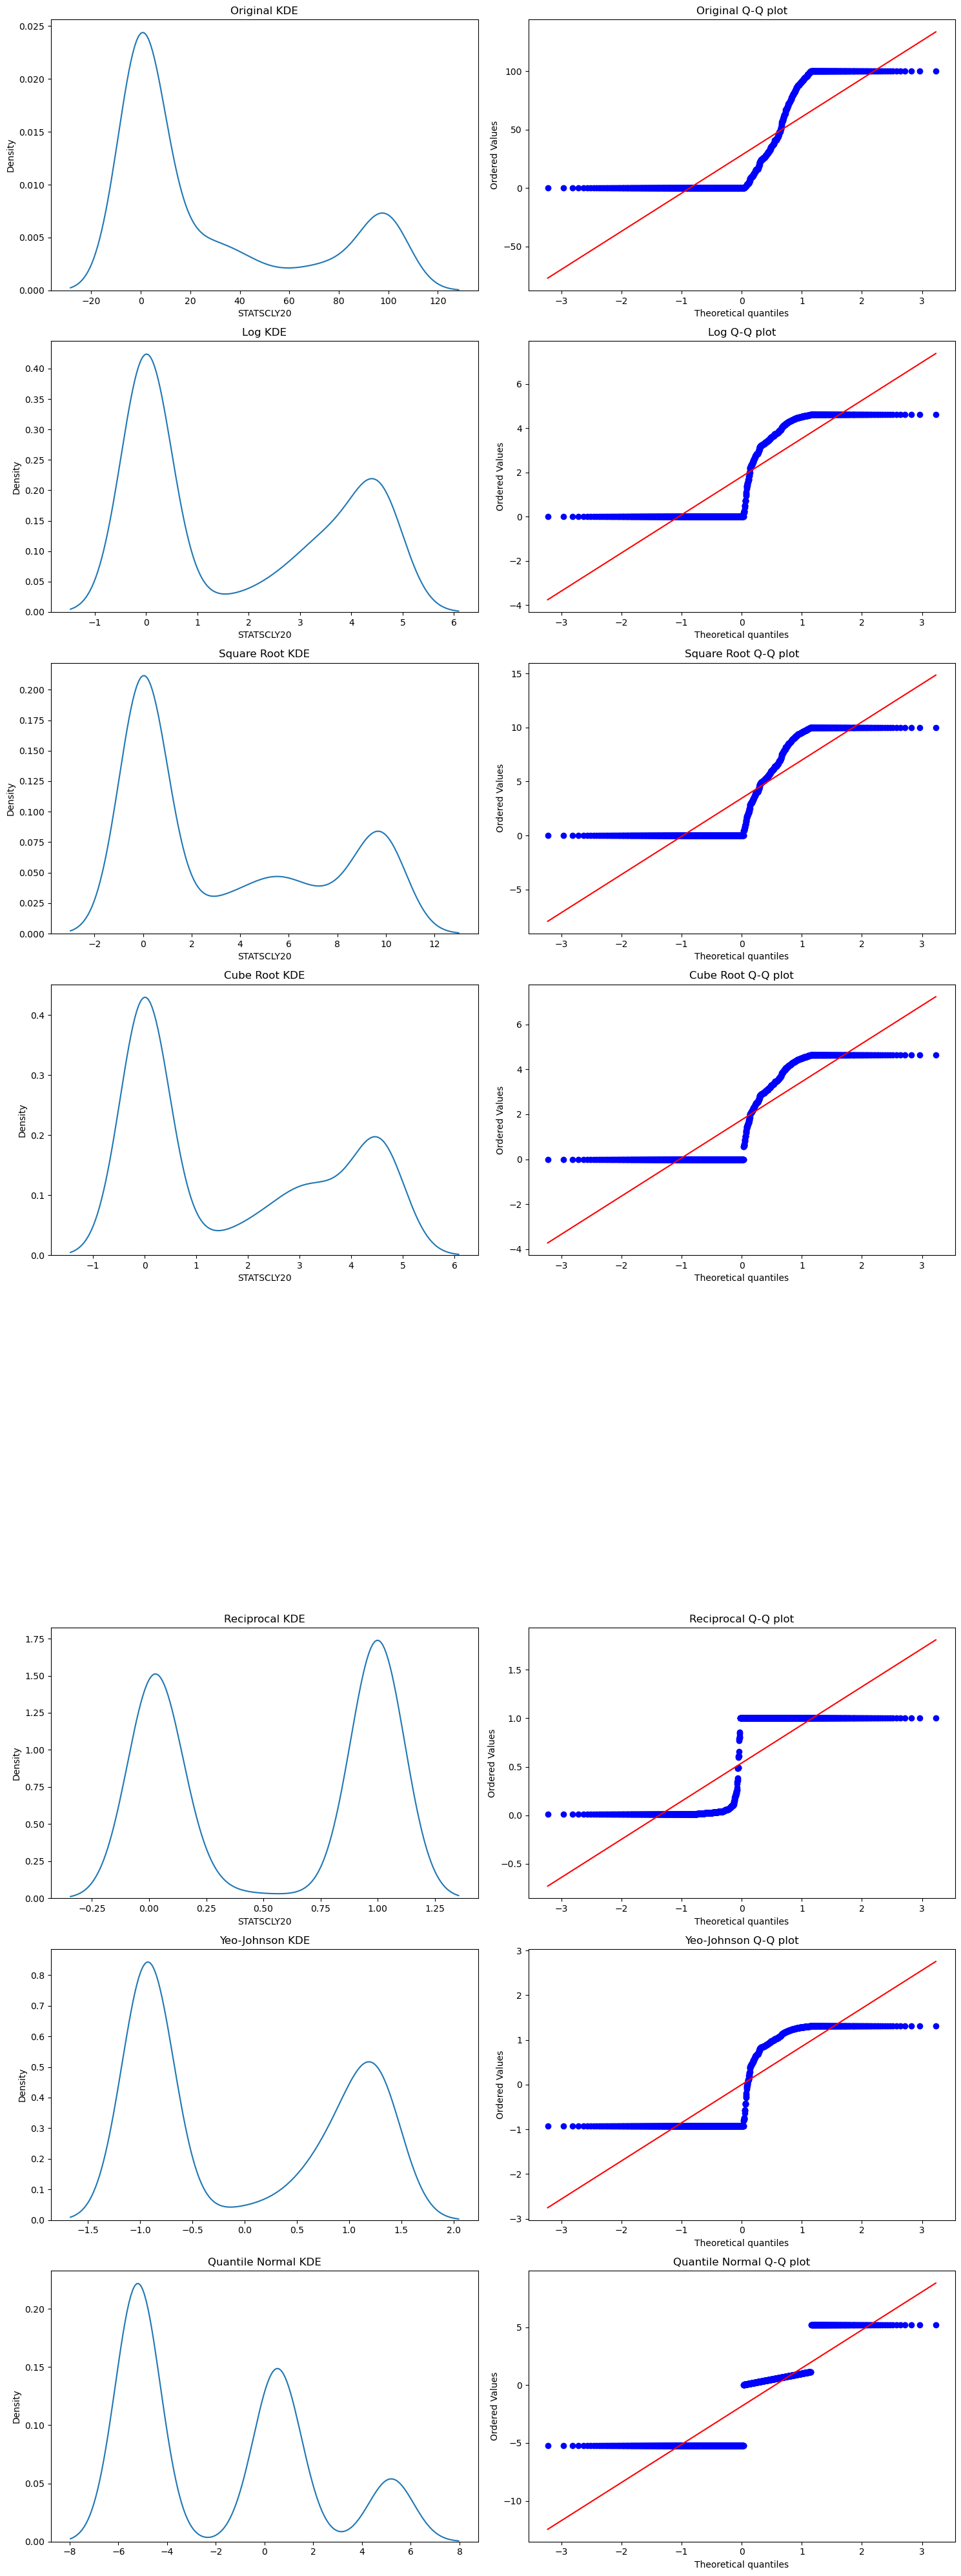

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.7112, p-value = 0.0000
  Anderson-Darling Test Statistic = 140.1787, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.7379, p-value = 0.0000
  Anderson-Darling Test Statistic = 129.1003, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.7550, p-value = 0.0000
  Anderson-Darling Test Statistic = 115.5957, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.7539, p-value = 0.0000
  Anderson-Darling Test Statistic = 118.0696, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.6665, p-value = 0.0000
  Anderson-Darling Test Statistic = 178.0072, Significance Level = [15.  10.   5.   2.5  1. ]

Yeo-Johnson Transformation:
  Shapiro-Wilk Test Statistic = 0.7223, p-value = 0.0000
  Anderson-Darling Test Stati

In [9]:
# Normality plots for STATSCLY20
normality(vadeq_strmsts, 'STATSCLY20')

#### RELIEF

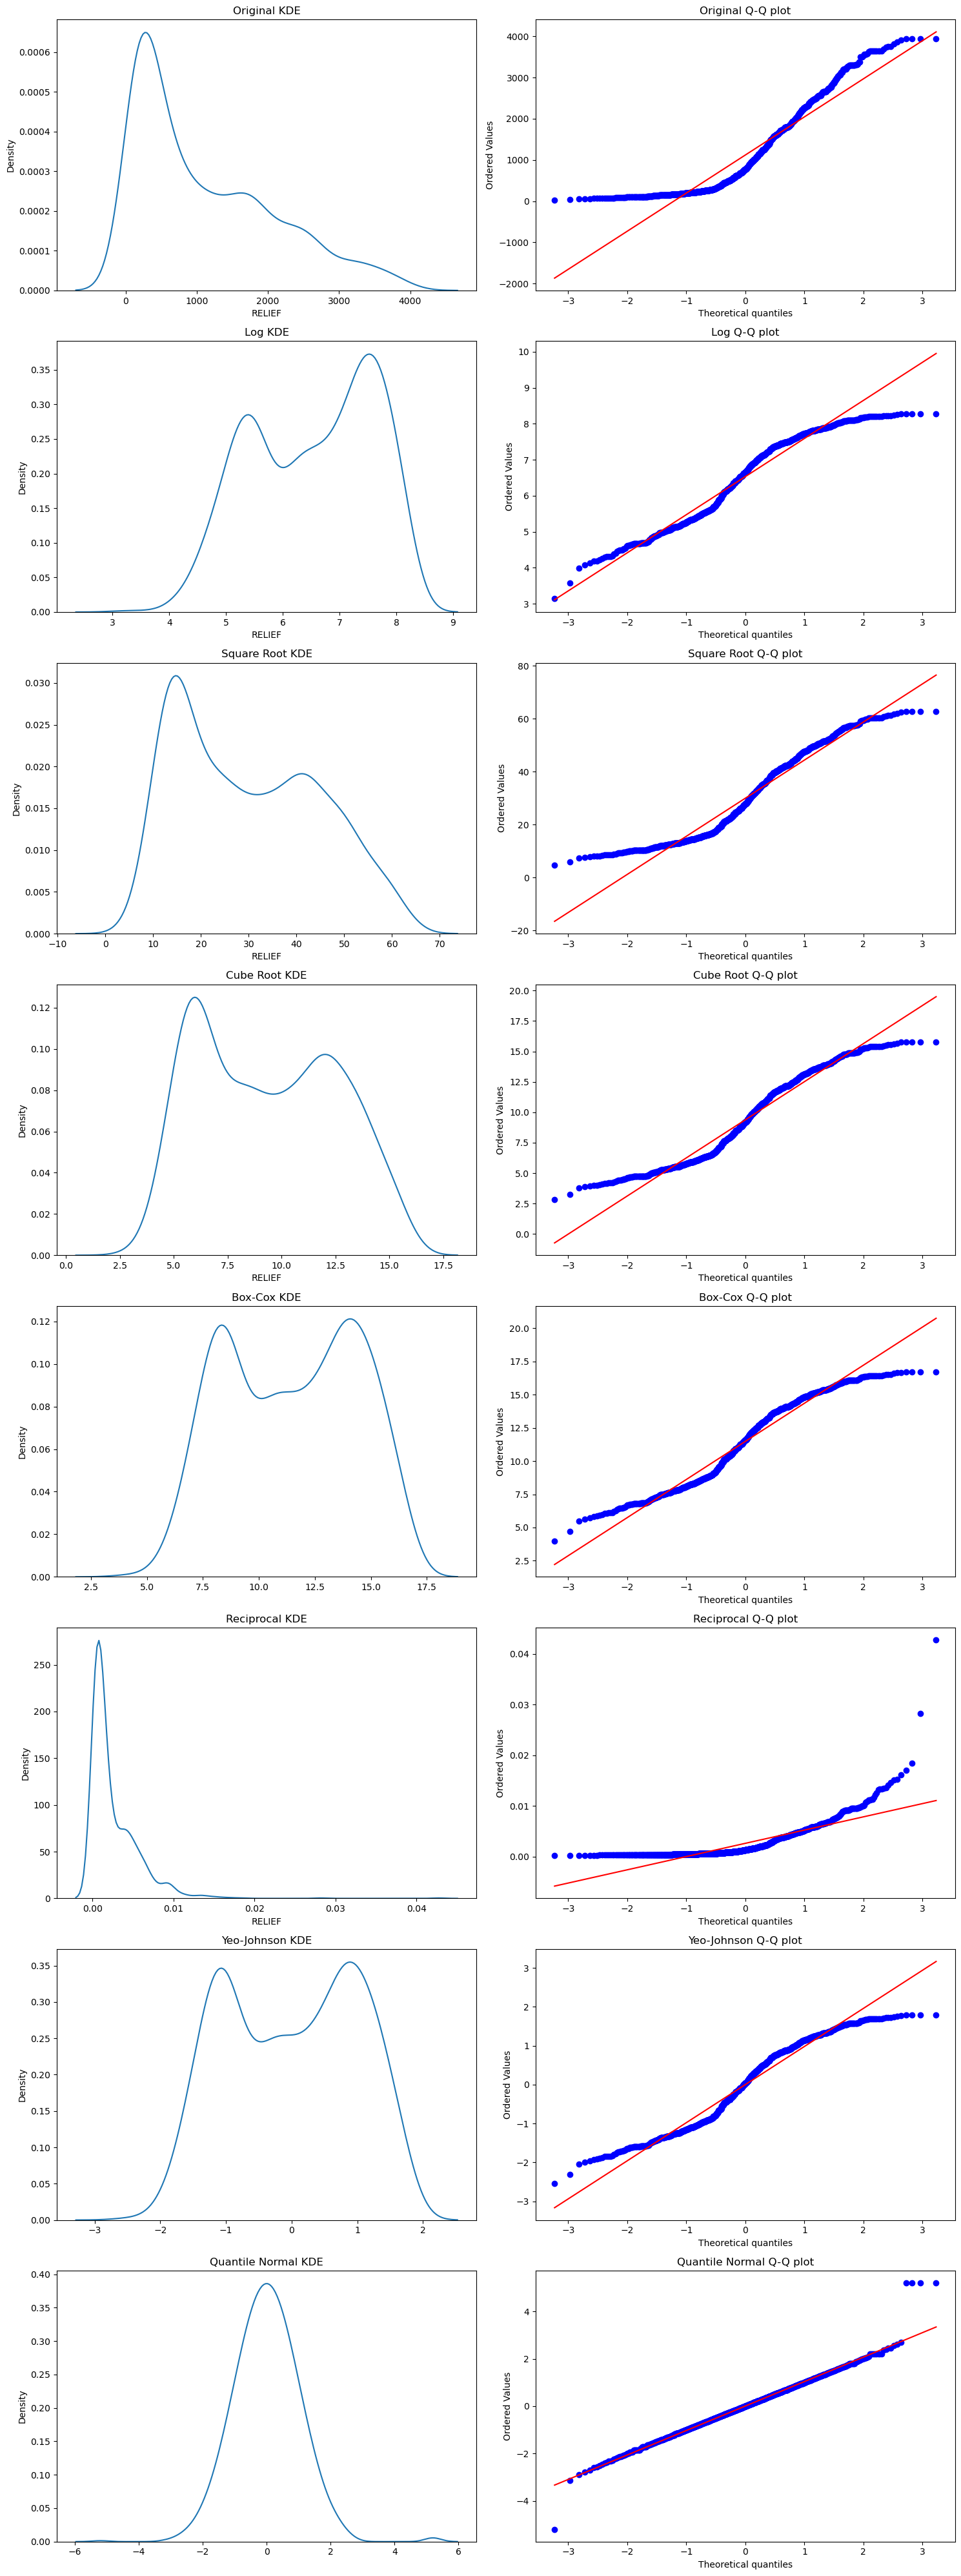

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.8800, p-value = 0.0000
  Anderson-Darling Test Statistic = 44.4623, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9502, p-value = 0.0000
  Anderson-Darling Test Statistic = 18.9506, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9395, p-value = 0.0000
  Anderson-Darling Test Statistic = 21.6610, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9501, p-value = 0.0000
  Anderson-Darling Test Statistic = 18.0452, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9541, p-value = 0.0000
  Anderson-Darling Test Statistic = 17.1112, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.6939, p-value = 0.0000
  Anderson-Darling Test Statistic = 84

In [10]:
# Normality plots for RELIEF
normality(vadeq_strmsts, 'RELIEF')

#### STATSPERM

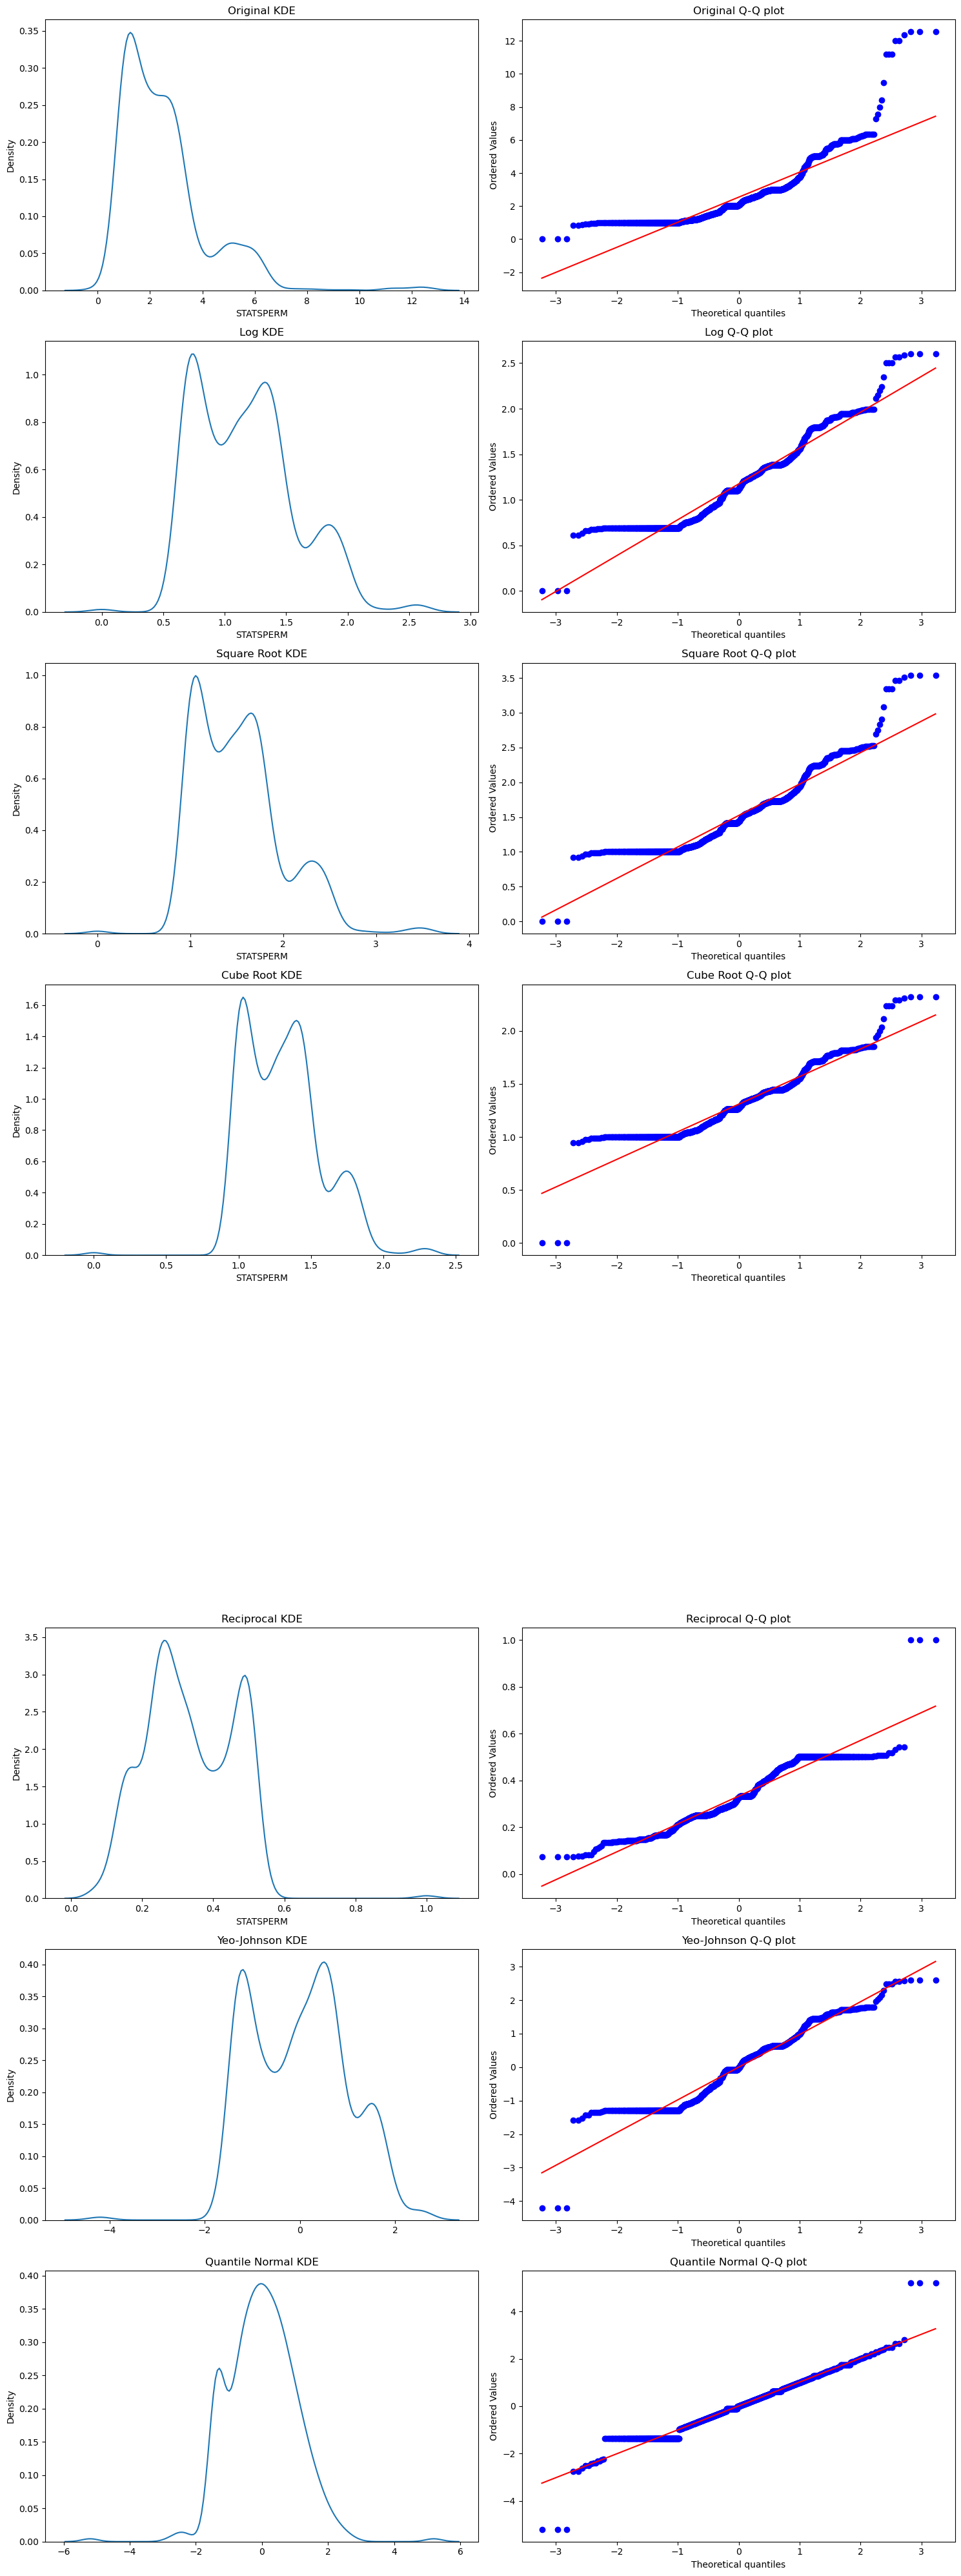

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.8078, p-value = 0.0000
  Anderson-Darling Test Statistic = 48.7696, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9390, p-value = 0.0000
  Anderson-Darling Test Statistic = 18.0060, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9154, p-value = 0.0000
  Anderson-Darling Test Statistic = 22.7355, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9277, p-value = 0.0000
  Anderson-Darling Test Statistic = 17.6962, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.9325, p-value = 0.0000
  Anderson-Darling Test Statistic = 17.8780, Significance Level = [15.  10.   5.   2.5  1. ]

Yeo-Johnson Transformation:
  Shapiro-Wilk Test Statistic = 0.9499, p-value = 0.0000
  Anderson-Darling Test Statistic 

In [11]:
# Normality plots for STATSPERM
normality(vadeq_strmsts, 'STATSPERM')

#### STATSCLY50

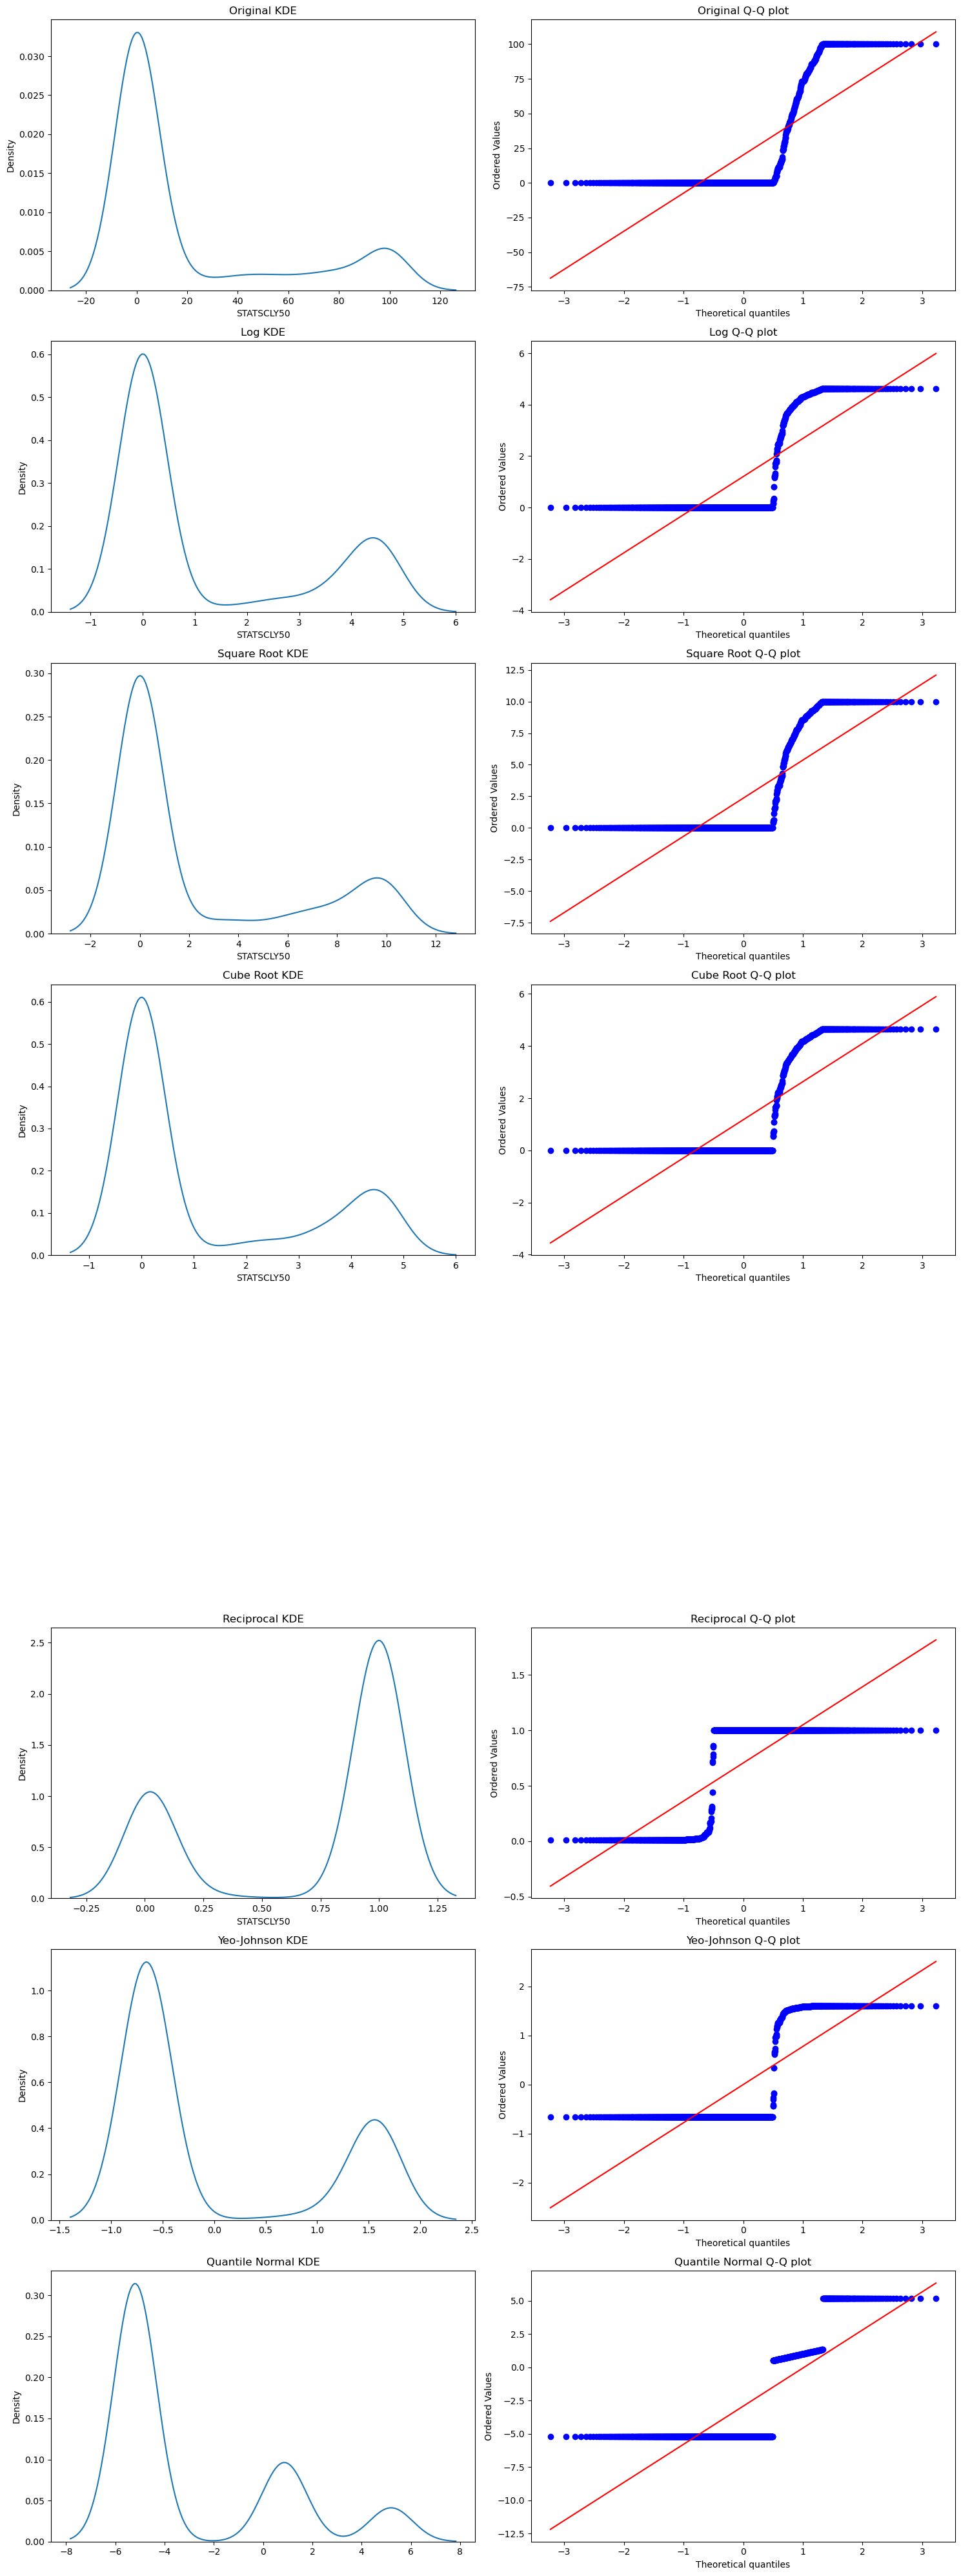

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.5949, p-value = 0.0000
  Anderson-Darling Test Statistic = 217.9680, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.6174, p-value = 0.0000
  Anderson-Darling Test Statistic = 212.2037, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.6215, p-value = 0.0000
  Anderson-Darling Test Statistic = 206.0716, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.6255, p-value = 0.0000
  Anderson-Darling Test Statistic = 205.7911, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.5922, p-value = 0.0000
  Anderson-Darling Test Statistic = 231.3596, Significance Level = [15.  10.   5.   2.5  1. ]

Yeo-Johnson Transformation:
  Shapiro-Wilk Test Statistic = 0.5988, p-value = 0.0000
  Anderson-Darling Test Stati

In [12]:
# Normality plots for STATSCLY50
normality(vadeq_strmsts, 'STATSCLY50')

#### LC11FORSHB

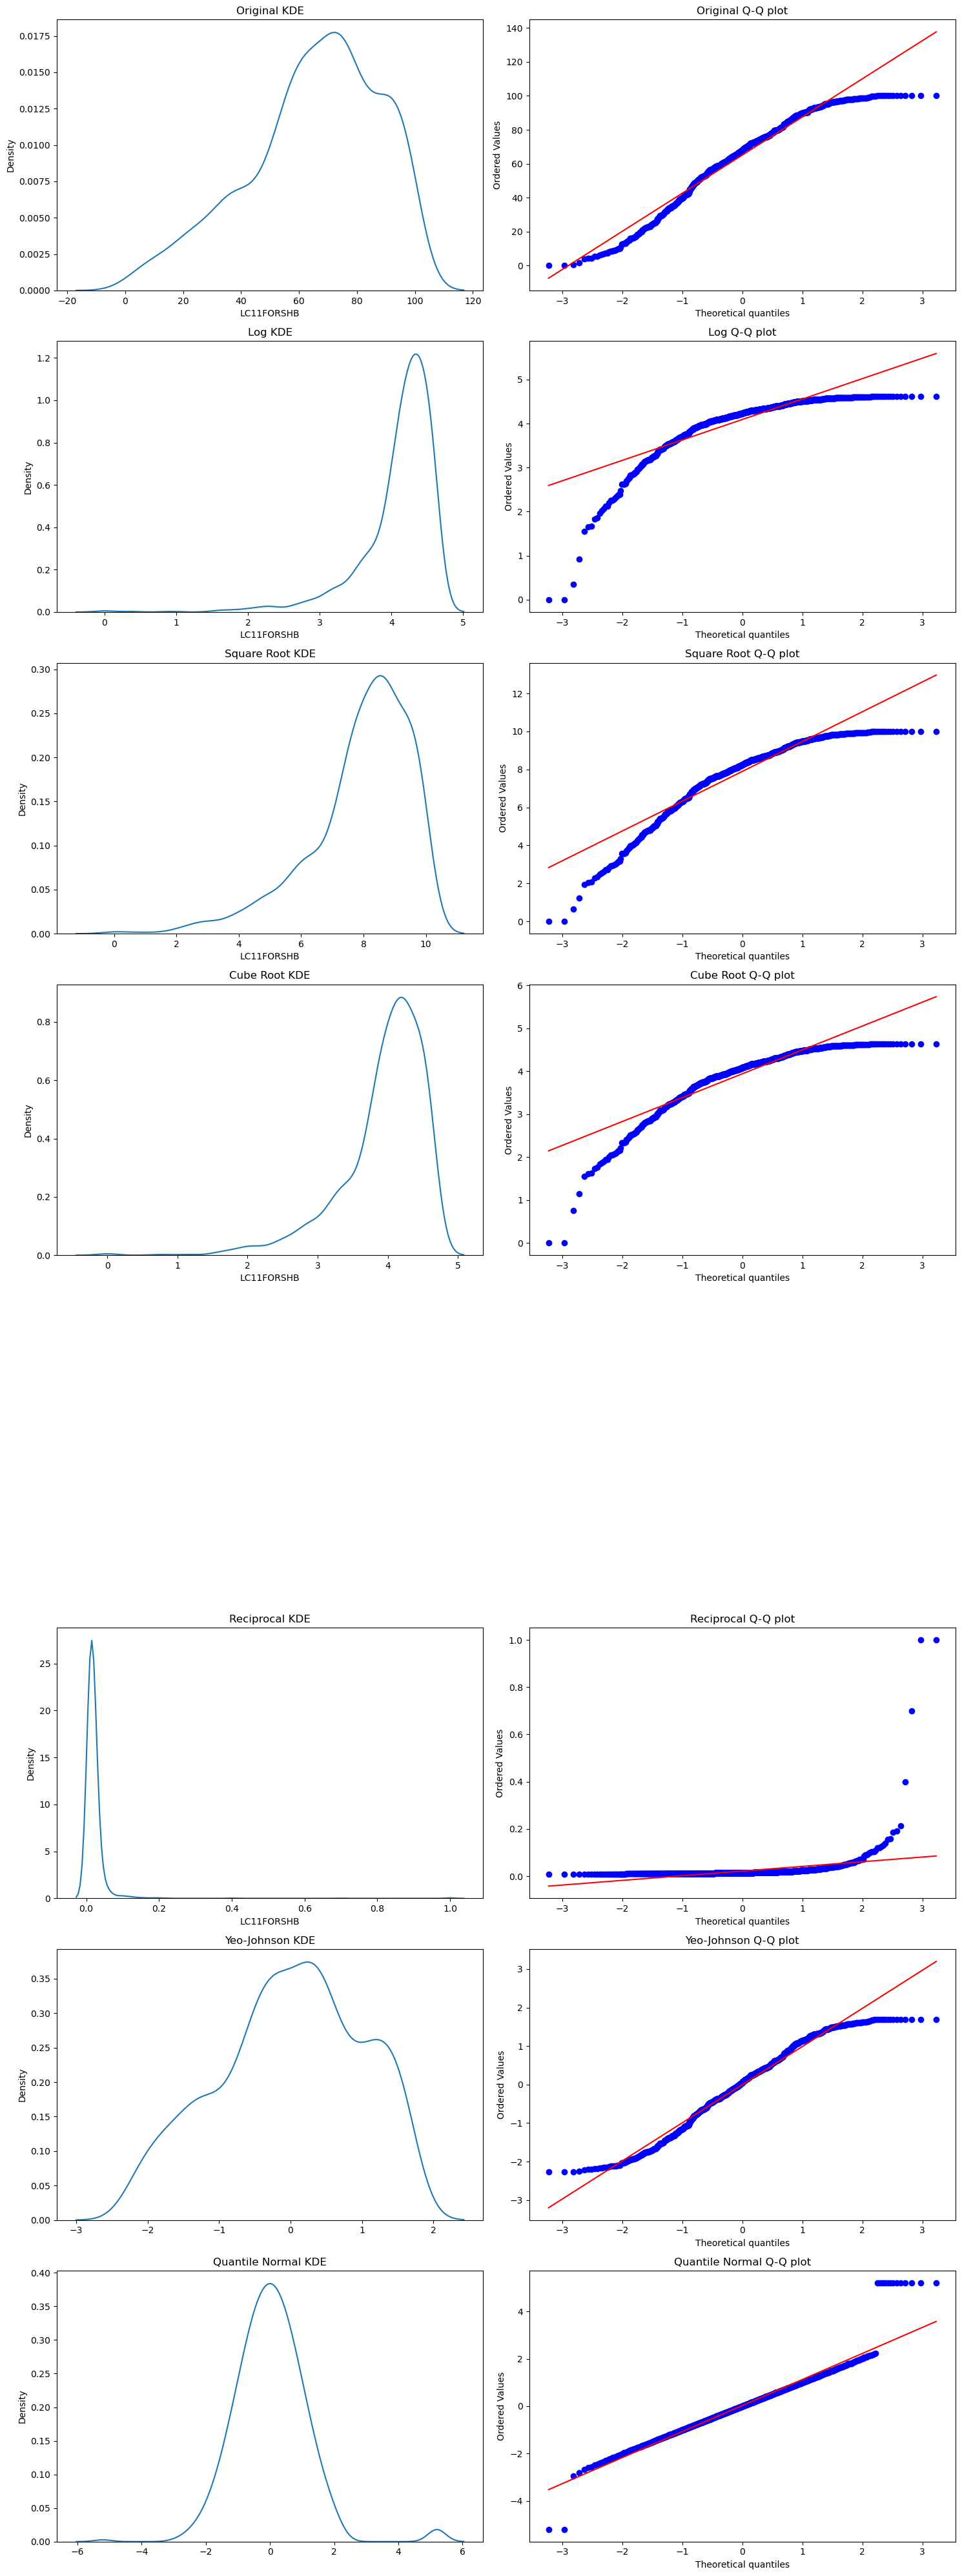

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.9595, p-value = 0.0000
  Anderson-Darling Test Statistic = 10.4021, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.7588, p-value = 0.0000
  Anderson-Darling Test Statistic = 62.4291, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.8998, p-value = 0.0000
  Anderson-Darling Test Statistic = 27.2913, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.8531, p-value = 0.0000
  Anderson-Darling Test Statistic = 37.5110, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.1537, p-value = 0.0000
  Anderson-Darling Test Statistic = 286.5160, Significance Level = [15.  10.   5.   2.5  1. ]

Yeo-Johnson Transformation:
  Shapiro-Wilk Test Statistic = 0.9737, p-value = 0.0000
  Anderson-Darling Test Statistic

In [13]:
# Normality plots for LC11FORSHB
normality(vadeq_strmsts, 'LC11FORSHB')

#### LC11CRPHAY

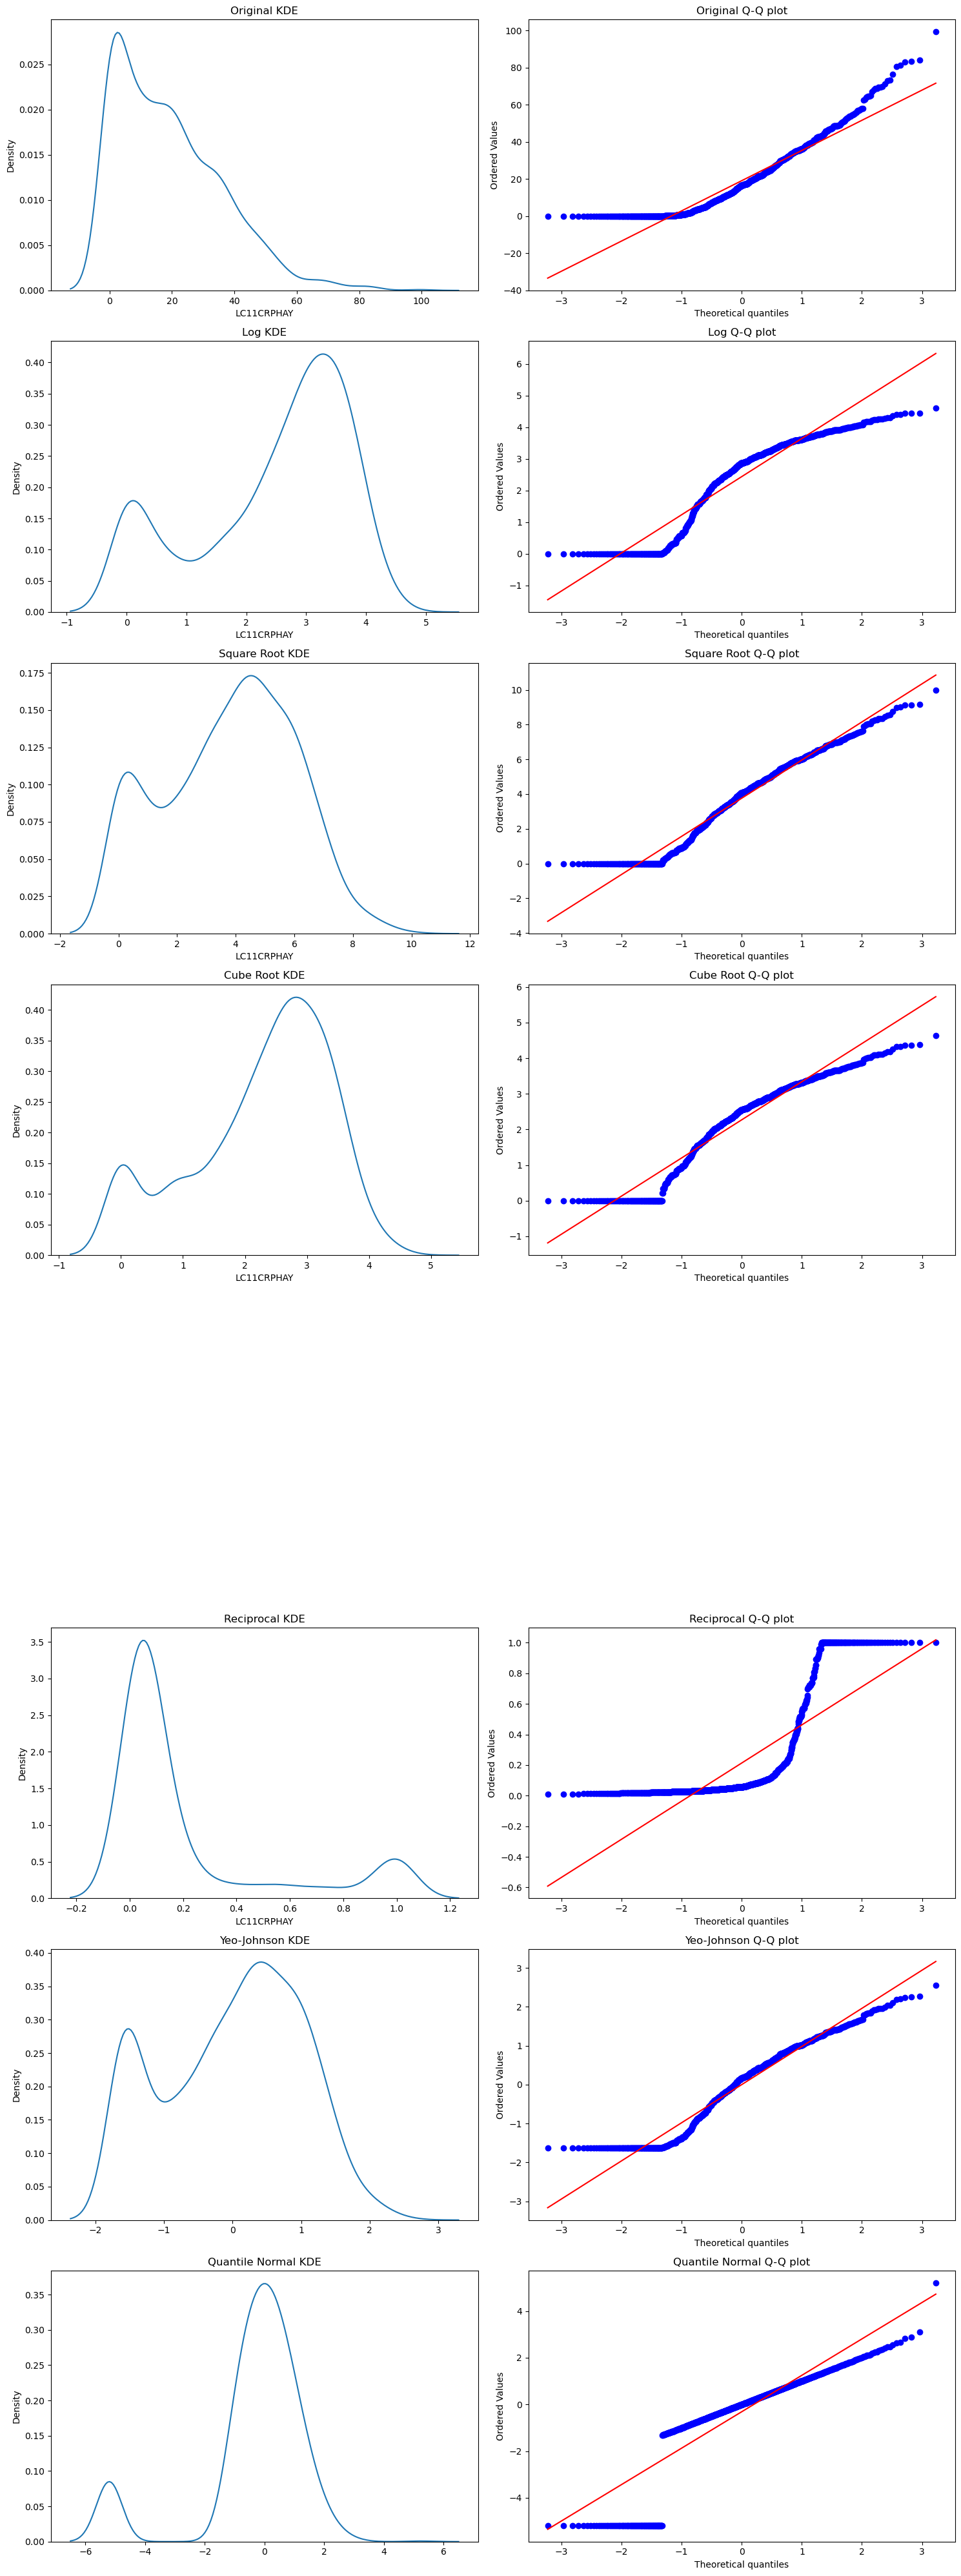

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.9121, p-value = 0.0000
  Anderson-Darling Test Statistic = 23.2025, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.8929, p-value = 0.0000
  Anderson-Darling Test Statistic = 41.9659, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9673, p-value = 0.0000
  Anderson-Darling Test Statistic = 9.3112, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9335, p-value = 0.0000
  Anderson-Darling Test Statistic = 23.6359, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.6236, p-value = 0.0000
  Anderson-Darling Test Statistic = 183.7230, Significance Level = [15.  10.   5.   2.5  1. ]

Yeo-Johnson Transformation:
  Shapiro-Wilk Test Statistic = 0.9540, p-value = 0.0000
  Anderson-Darling Test Statistic 

In [14]:
# Normality plots for LC11CRPHAY
normality(vadeq_strmsts, 'LC11CRPHAY')

#### I24H2Y

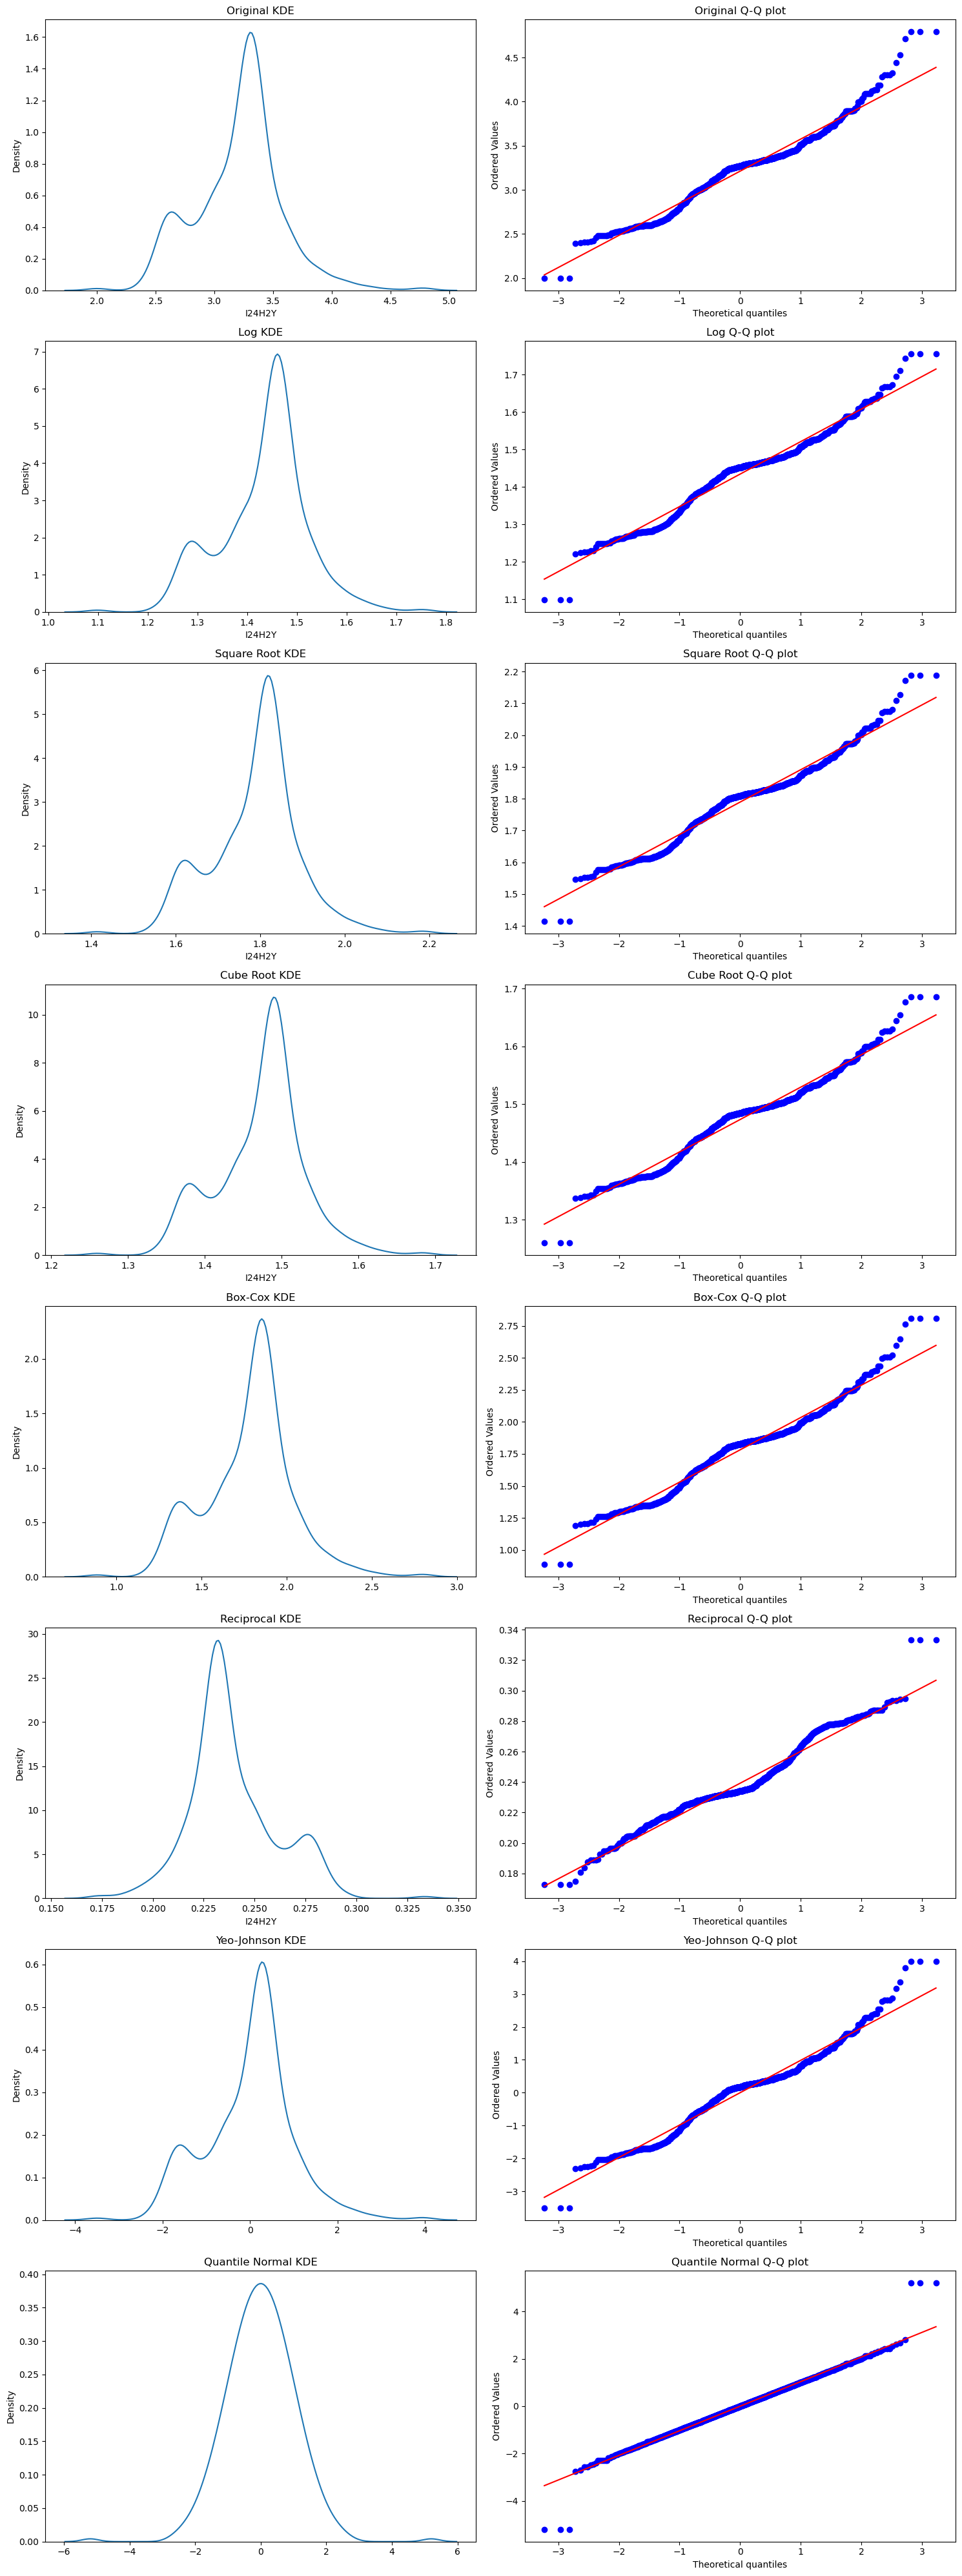

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.9648, p-value = 0.0000
  Anderson-Darling Test Statistic = 14.3748, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9651, p-value = 0.0000
  Anderson-Darling Test Statistic = 17.6024, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9662, p-value = 0.0000
  Anderson-Darling Test Statistic = 16.2715, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9656, p-value = 0.0000
  Anderson-Darling Test Statistic = 17.1144, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9663, p-value = 0.0000
  Anderson-Darling Test Statistic = 15.4586, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.9541, p-value = 0.0000
  Anderson-Darling Test Statistic = 22

In [15]:
# Normality plots for I24H2Y
normality(vadeq_strmsts, 'I24H2Y')

#### PRECIP

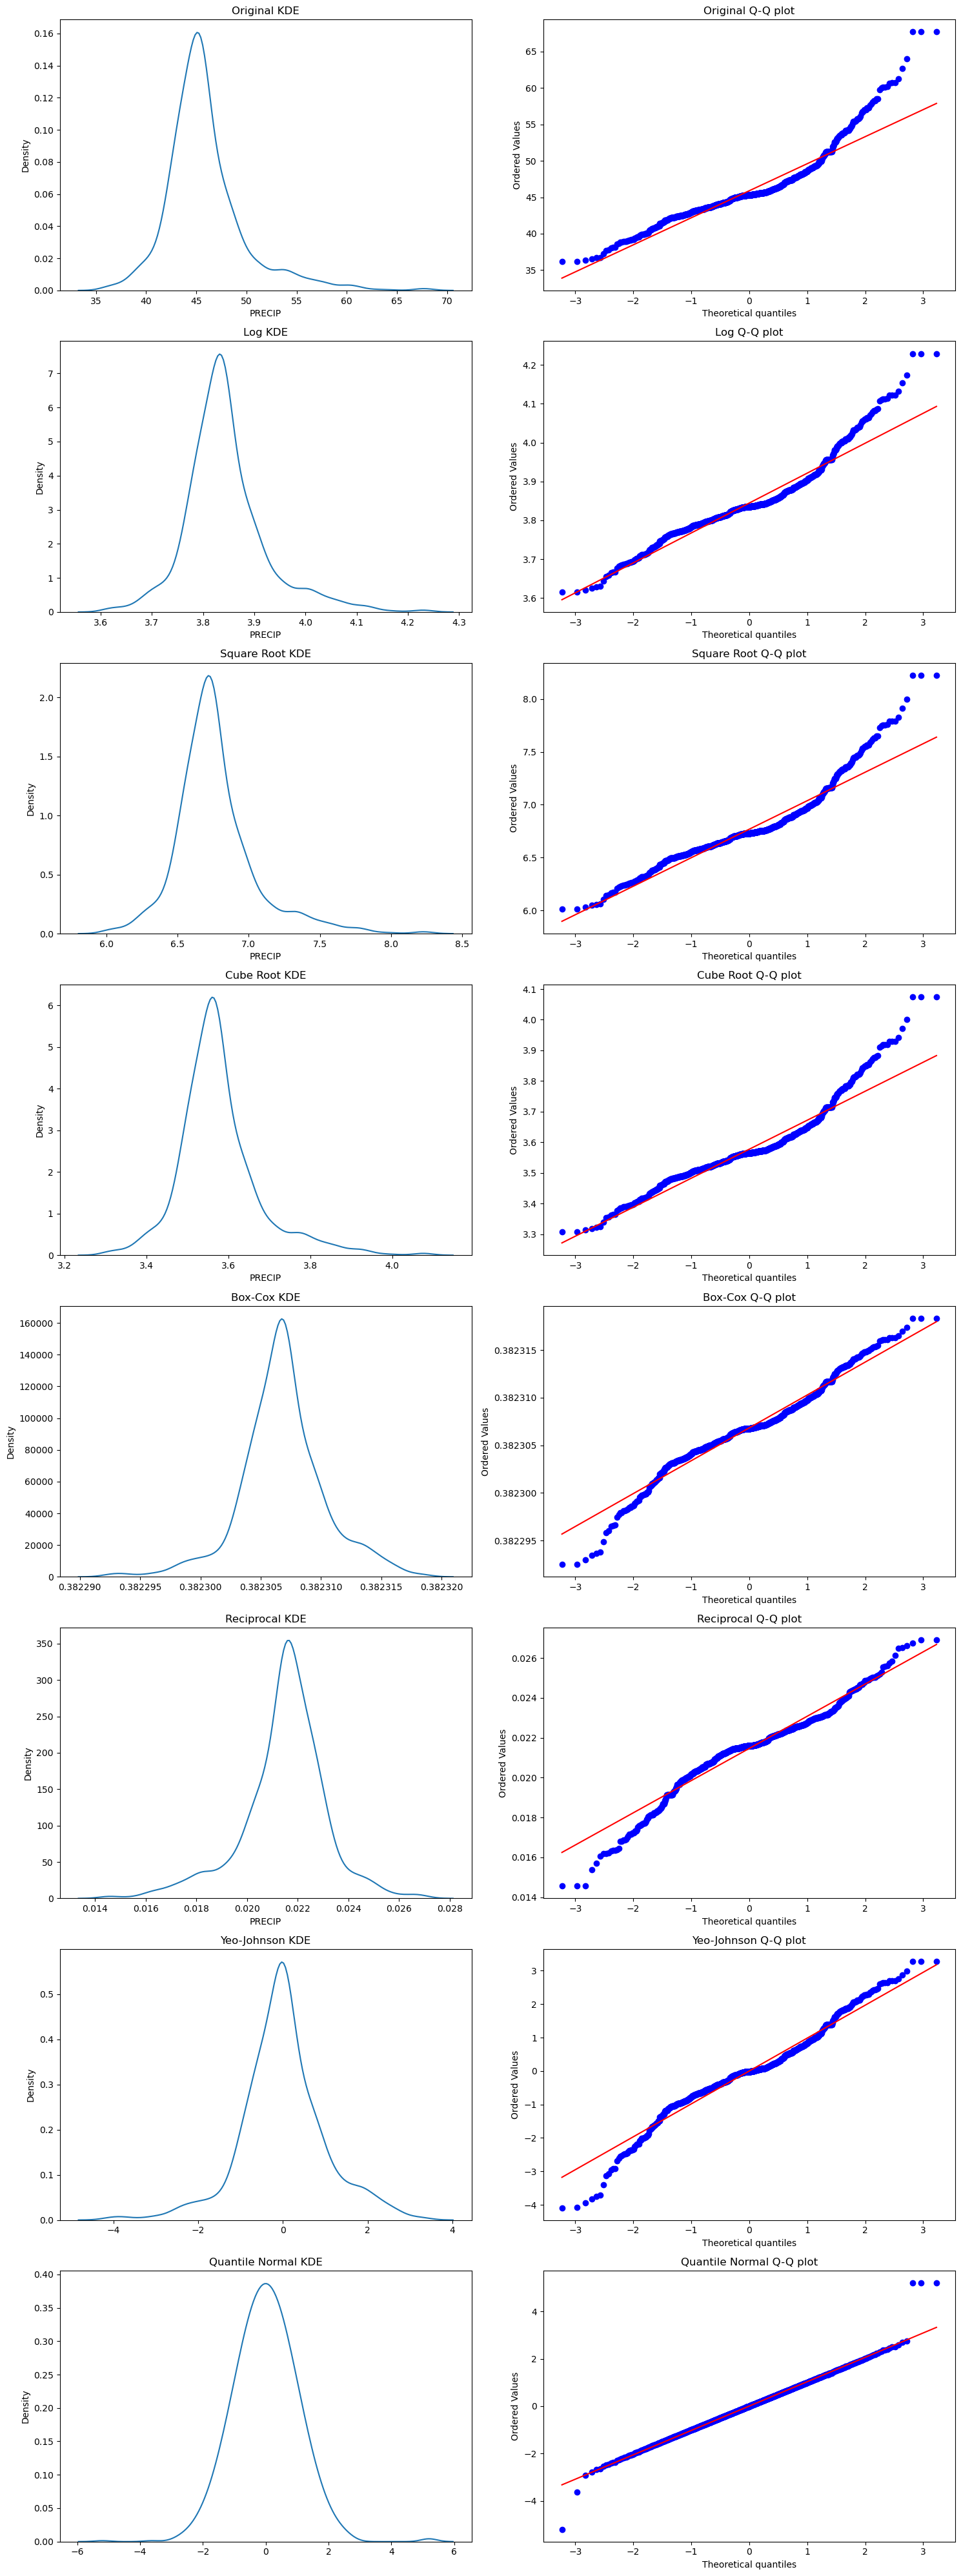

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.8862, p-value = 0.0000
  Anderson-Darling Test Statistic = 36.0863, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9241, p-value = 0.0000
  Anderson-Darling Test Statistic = 26.5112, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9070, p-value = 0.0000
  Anderson-Darling Test Statistic = 30.8544, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9133, p-value = 0.0000
  Anderson-Darling Test Statistic = 29.2717, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9639, p-value = 0.0000
  Anderson-Darling Test Statistic = 13.7023, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.9496, p-value = 0.0000
  Anderson-Darling Test Statistic = 19

In [16]:
# Normality plots for PRECIP
normality(vadeq_strmsts, 'PRECIP')

#### Year

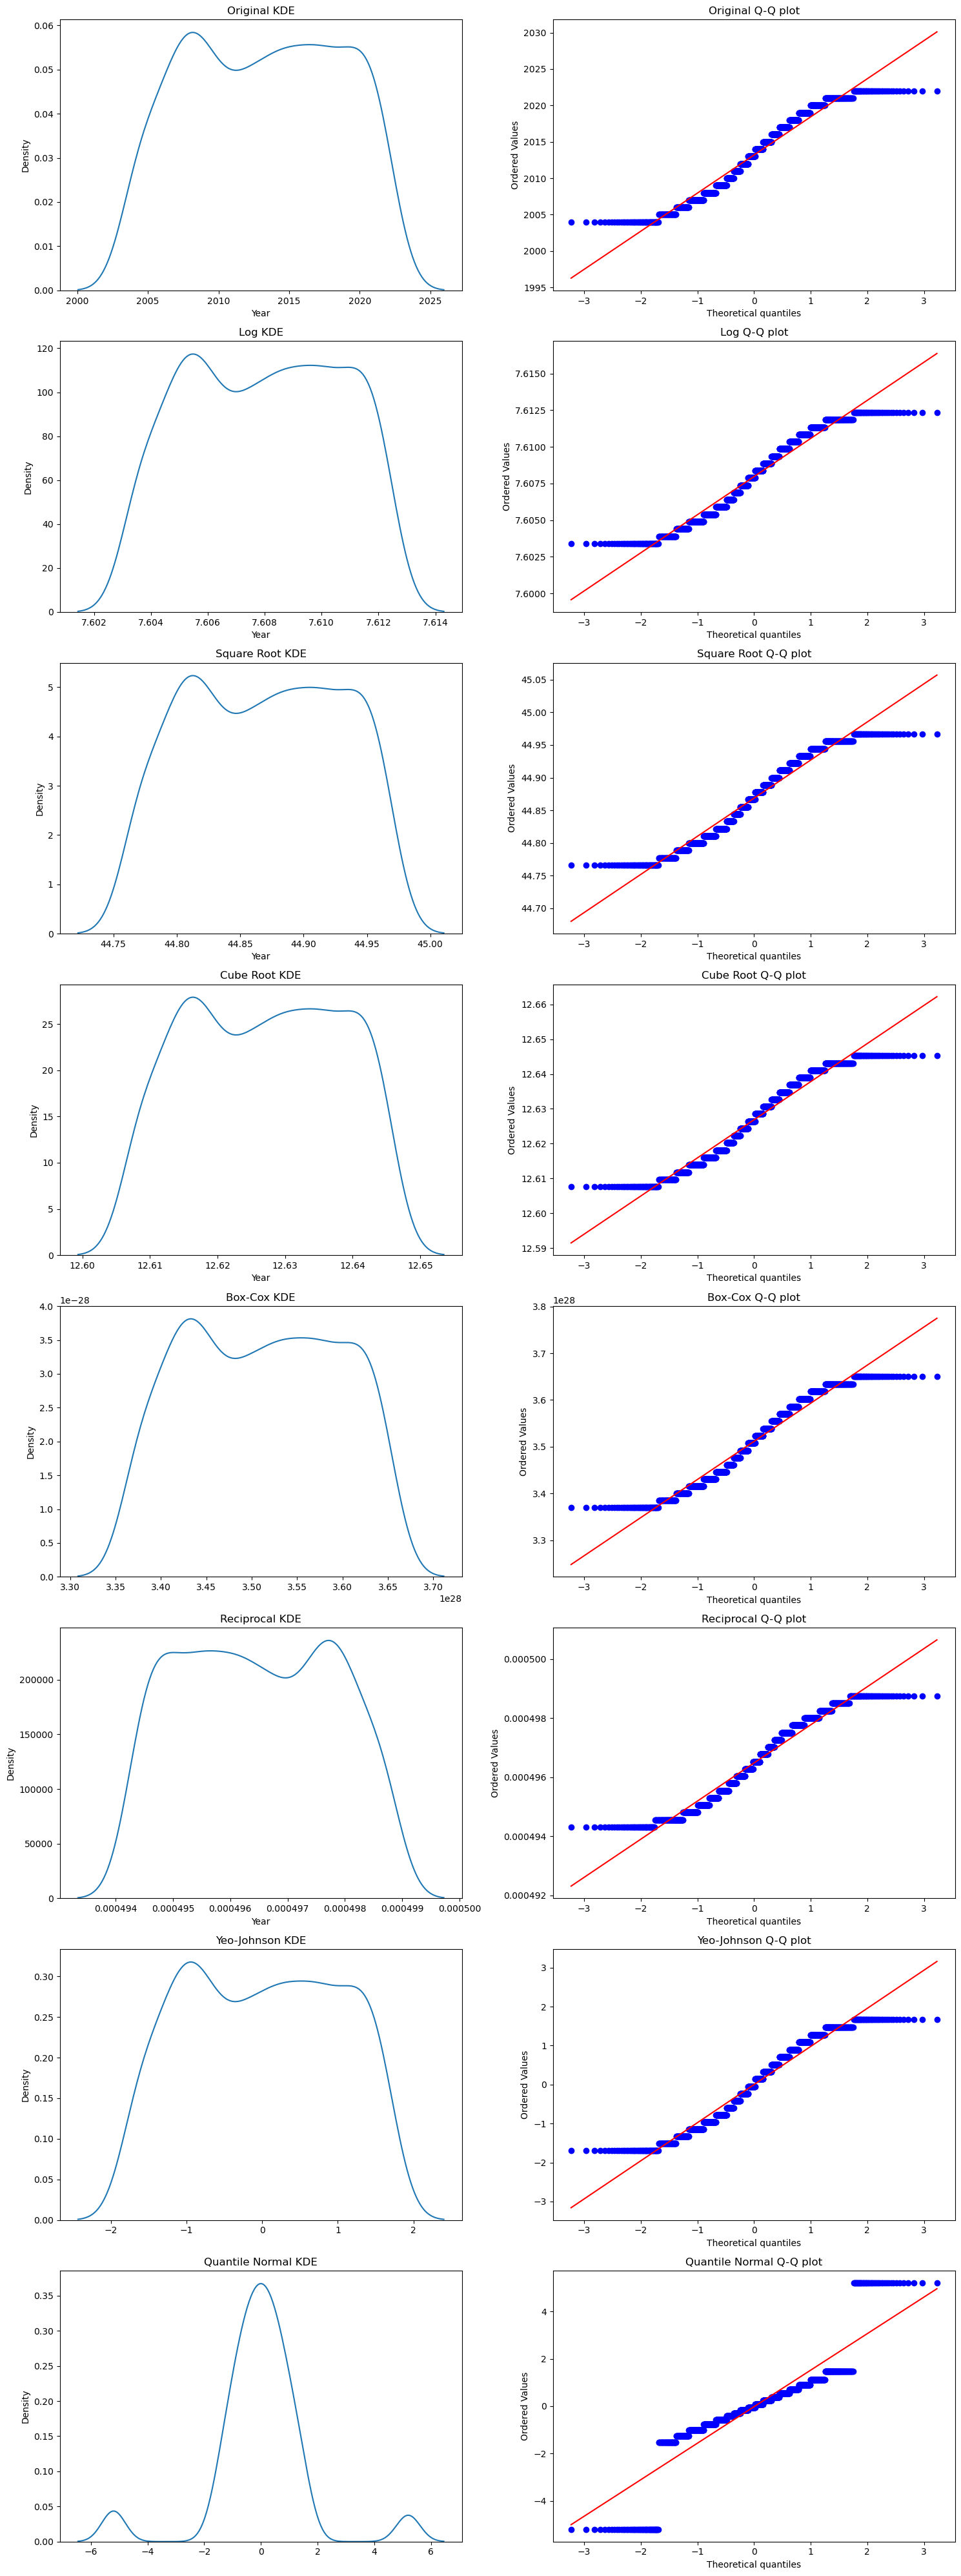

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.9503, p-value = 0.0000
  Anderson-Darling Test Statistic = 14.7018, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9503, p-value = 0.0000
  Anderson-Darling Test Statistic = 14.7065, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9503, p-value = 0.0000
  Anderson-Darling Test Statistic = 14.7041, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.9503, p-value = 0.0000
  Anderson-Darling Test Statistic = 14.7049, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9503, p-value = 0.0000
  Anderson-Darling Test Statistic = 14.6936, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.9503, p-value = 0.0000
  Anderson-Darling Test Statistic = 14

In [17]:
# Normality plot for Year
normality(vadeq_strmsts, 'Year')

#### DRNAREA

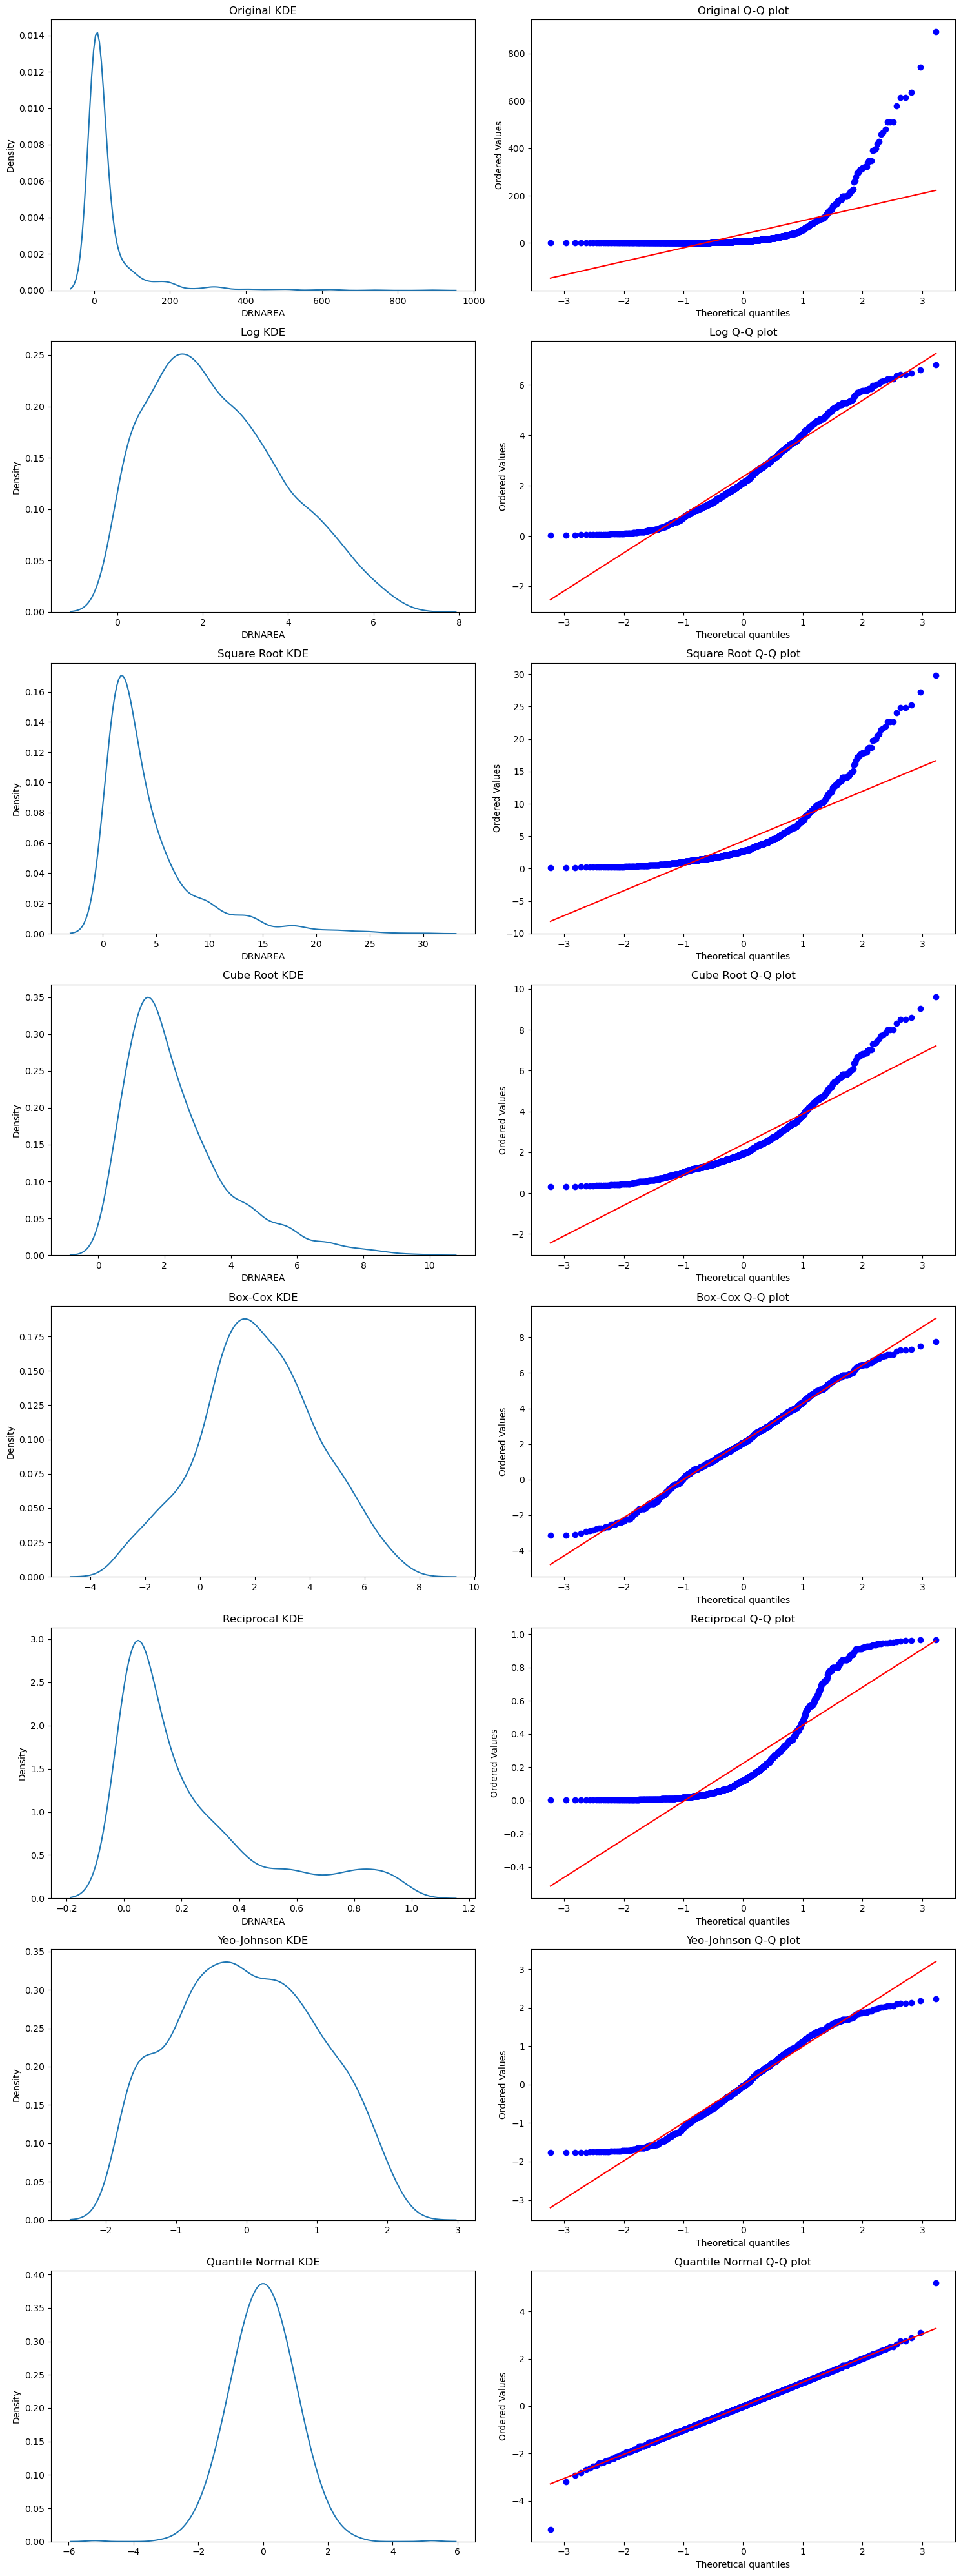

Original Transformation:
  Shapiro-Wilk Test Statistic = 0.4608, p-value = 0.0000
  Anderson-Darling Test Statistic = 201.1603, Significance Level = [15.  10.   5.   2.5  1. ]

Log Transformation:
  Shapiro-Wilk Test Statistic = 0.9612, p-value = 0.0000
  Anderson-Darling Test Statistic = 10.4347, Significance Level = [15.  10.   5.   2.5  1. ]

Square Root Transformation:
  Shapiro-Wilk Test Statistic = 0.7681, p-value = 0.0000
  Anderson-Darling Test Statistic = 76.3468, Significance Level = [15.  10.   5.   2.5  1. ]

Cube Root Transformation:
  Shapiro-Wilk Test Statistic = 0.8836, p-value = 0.0000
  Anderson-Darling Test Statistic = 36.2339, Significance Level = [15.  10.   5.   2.5  1. ]

Box-Cox Transformation:
  Shapiro-Wilk Test Statistic = 0.9952, p-value = 0.0013
  Anderson-Darling Test Statistic = 0.7995, Significance Level = [15.  10.   5.   2.5  1. ]

Reciprocal Transformation:
  Shapiro-Wilk Test Statistic = 0.7953, p-value = 0.0000
  Anderson-Darling Test Statistic = 80

In [18]:
# Normality plots for DRNAREA
normality(vadeq_strmsts, 'DRNAREA')

### Step 2b. Apply transformations

In [19]:
# Define transformers
pt = PowerTransformer(method = 'yeo-johnson')
qt = QuantileTransformer(output_distribution = 'normal')

In [21]:
# Transform features based on visual and statistical results from above

# Create new transformed column for each feature required
vadeq_strmsts['Bankfull Shear Velocity (m/s) (QT)'] = qt.fit_transform(vadeq_strmsts['Bankfull Shear Velocity (m/s)'].values.reshape(-1, 1))
vadeq_strmsts['Avg Soil Depth (QT)'] = qt.fit_transform(vadeq_strmsts['STATSGODEP'].values.reshape(-1, 1))
vadeq_strmsts['Avg Basin Elev (QT)'] = qt.fit_transform(vadeq_strmsts['ELEV'].values.reshape(-1, 1))
vadeq_strmsts['% Soils w/ 10-20% Clay (sqrt)'] = np.sqrt(vadeq_strmsts['STATSCLY20'])
vadeq_strmsts['Relief (QT)'] = qt.fit_transform(vadeq_strmsts['RELIEF'].values.reshape(-1, 1))
vadeq_strmsts['Avg Soil Permeability (log)'] = np.log((vadeq_strmsts['STATSPERM']) + 1)
vadeq_strmsts['% Soils w/ 40-50% Clay (cbrt)'] = np.power(vadeq_strmsts['STATSCLY50'], 1/3)
vadeq_strmsts['% Forests and Shrub Lands (YJ)'] = pt.fit_transform(vadeq_strmsts['LC11FORSHB'].values.reshape(-1, 1))
vadeq_strmsts['% Crop and Pasture (sqrt)'] = np.sqrt(vadeq_strmsts['LC11CRPHAY'])
vadeq_strmsts['Max 24-Hr Precip for 2-Yr RP (QT)'] = qt.fit_transform(vadeq_strmsts['I24H2Y'].values.reshape(-1, 1))
vadeq_strmsts['Avg Annual Precipitation (QT)'] = qt.fit_transform(vadeq_strmsts['PRECIP'].values.reshape(-1, 1))
vadeq_strmsts['Drainage Area (QT)'] = qt.fit_transform(vadeq_strmsts['DRNAREA'].values.reshape(-1, 1))

In [24]:
# Select columns based on visual and statistical results
vadeq_strmsts = vadeq_strmsts[['StationID',
                                 'Xembed',
                               'LATITUDE',
                               'LONGITUDE',
                               'Date',
                               'Bankfull Shear Velocity (m/s) (QT)',
                                'Avg Soil Depth (QT)', 
                               'Avg Basin Elev (QT)',
                               '% Soils w/ 10-20% Clay (sqrt)', 
                               'Relief (QT)',
                               'Avg Soil Permeability (log)',
                               '% Soils w/ 40-50% Clay (cbrt)',
                               '% Forests and Shrub Lands (YJ)',
                               '% Crop and Pasture (sqrt)',
                               'Max 24-Hr Precip for 2-Yr RP (QT)', 
                               'Avg Annual Precipitation (QT)',
                                'Year', # Original has same Shapiro-Wilk stat AND time is best left unchanged,
                                'Drainage Area (QT)',
                                'Peak Flow #: 1551', 
                               'Peak Flow #: 1552', 
                               'Peak Flow #: 1553',
                               'Peak Flow #: 1554', 
                               'Peak Flow #: 1555']]

In [25]:
# Rename respective columns for plotting purposes
vadeq_strmsts = vadeq_strmsts.rename(columns = {'StationID':'Station ID',
                                                'LATITUDE':'Latitude',
                                                'LONGITUDE':'Longitude',
                                                  'Xembed':'Streambed Embeddedness (%)'})

In [26]:
# Display dataframe
vadeq_strmsts

Index(['Station ID', 'Streambed Embeddedness (%)', 'Latitude', 'Longitude',
       'Date', 'Bankfull Shear Velocity (m/s) (QT)', 'Avg Soil Depth (QT)',
       'Avg Basin Elev (QT)', '% Soils w/ 10-20% Clay (sqrt)', 'Relief (QT)',
       'Avg Soil Permeability (log)', '% Soils w/ 40-50% Clay (cbrt)',
       '% Forests and Shrub Lands (YJ)', '% Crop and Pasture (sqrt)',
       'Max 24-Hr Precip for 2-Yr RP (QT)', 'Avg Annual Precipitation (QT)',
       'Year', 'Drainage Area (QT)', 'Peak Flow #: 1551', 'Peak Flow #: 1552',
       'Peak Flow #: 1553', 'Peak Flow #: 1554', 'Peak Flow #: 1555'],
      dtype='object')

## Step 3. Export to Excel

In [28]:
# Create path and push to model_ready folder
mdl_path = os.path.join(BASE_DIR, "data", "model_ready", "vadeq_strmsts_mdl.xlsx")
vadeq_strmsts.to_excel(mdl_path)
print(f"Dataset saved to {mdl_path}")

Dataset saved to C:\Users\reill\Documents\Virginia Tech\Czuba Research\Embeddedness\GitHub\Embeddedness_ML_XAI\data\model_ready\vadeq_strmsts_mdl.xlsx
